# <span style="color:orange">Quality Data Analysis - Project Work </span>
## Team 14

### Course Details:
- Academic Year: 2024-2025

### Project Details:
- Title: In-situ monitoring of LPBF with dual pyrometry

### Team Members:
- Vitor Tavares Coifman
- Kann Turgay
- Ahmet Tarık Özbek
- Sophia Shuleva

### Instructor:
- Panagiotis Tsiamyrtzis

## PHASE 2

**Introduction**

Phase 2 continues the statistical process monitoring project by testing the effectiveness and generalizability of control charts developed in Phase 1 using a new, independent dataset. In the previous phase, multiple approaches were tested to monitor temperature dynamics in the Laser Powder Bed Fusion (LPBF) process based on high-frequency dual pyrometry data.

After extensive experimentation and evaluation, the following models were selected as the most reliable and generalizable:

I-MR Control Charts constructed for means of tracks within a single layer using ARIMA
I-MR Control Charts constructed for maximum values of each track across adjacent layers using ARIMA
I-MR Control Charts constructed for minimum values of each track across adjacent layers using ARIMA
These models were chosen for their ability to detect both systemic and localized temperature anomalies. The first model enables fine-grained, track-wise detection of deviations in layer means. The second and third models offer generalized detection of isolated temperature spikes or drops, even across layers, though with limited precision in localizing exact points.

Other approaches were discarded for various reasons, including weak modeling performance (e.g., Approaches 2, 3, 9), poor interpretability (e.g., Approaches 5, 6), excessive differencing or overfitting (e.g., Approaches 7A, 7B), and limited generalizability (e.g., Approach 10). Notably, models relying on binning by t or using entire layers as single units were also excluded due to their failure to align with LPBF’s inherently track-based process structure.

Phase 2 aims to validate the selected models from Phase 1 by applying them to new layers from the second half of the print job. These layers were not used during model construction and allow us to test the models’ robustness under previously unseen process conditions.

The key methodological steps include:

1. Data Selection and Preprocessing

The second-half data is prepared using the same preprocessing pipeline as in Phase 1. This includes filtering tracks with insufficient size, excluding noisy edge regions, and applying transformations or outlier removal as previously established.

2. Fixed Model Deployment

ARIMA models and Shewhart I-MR control limits, as defined in Phase 1, are reused without refitting. This constraint ensures a true test of generalization. Residuals are extracted and fed directly into the control chart structures.

3. Evaluation of Control Charts

We analyze whether control limits are respected in the new data, focusing on:
- Out-of-control signals and their position
- The nature of detected deviations (systematic vs. isolated)
- Compliance of residuals with assumptions (e.g., independence, normality)

4. Interpretation and Reflection

Finally, results are interpreted to determine whether model assumptions hold under new data and whether the models are still useful for identifying process instabilities. Where appropriate, we discuss trade-offs and recommendations for future refinement.

In [278]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import qdatoolkit as qda
import seaborn as   sns
import statsmodels.api as sm
from sklearn.preprocessing import PowerTransformer

pd.options.mode.chained_assignment = None  # default='warn'

In [279]:
all_layers = {}
i = 624
j= 1
while i <= 928:
    layer_name = 'layer_'+str(i)
    layer = pd.read_csv('Data_P2/'+layer_name+'.csv')
    all_layers[layer_name] = layer
    if i%10 == 8:
        i += 96
        j+=1
    else:
        i+=1
for i in all_layers:
    if i =="layer_624":
        full_frame = all_layers[i]
    else:
        full_frame = pd.concat([full_frame,all_layers[i]])
full_frame = full_frame.reset_index().drop(['index'], axis=1)

In [280]:
full_frame

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel
0,1.3063e+08,26.039,-66.398,28.96,724,800.0,791.0,1600.3,0,291,0.0000,0.0
1,1.3063e+08,26.044,-66.403,28.96,724,787.0,784.0,1591.9,0,291,0.0072,10.0
2,1.3063e+08,26.052,-66.407,28.96,724,807.0,797.0,1601.6,0,291,0.0144,20.0
3,1.3063e+08,26.058,-66.412,28.96,724,817.0,815.0,1590.4,0,291,0.0216,30.0
4,1.3063e+08,26.062,-66.421,28.96,724,840.0,823.0,1610.6,0,291,0.0288,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4123449,8.4993e+07,38.059,-54.465,37.12,928,843.0,903.0,1515.3,162,279,0.0000,0.0
4123450,8.4993e+07,38.059,-54.468,37.12,928,849.0,908.0,1516.9,162,279,0.0050,10.0
4123451,8.4993e+07,38.067,-54.469,37.12,928,845.0,918.0,1501.2,162,279,0.0099,20.0
4123452,8.4993e+07,38.071,-54.475,37.12,928,857.0,926.0,1506.6,162,279,0.0149,30.0


# Approach 1: Tracks on a Single Layer

- **Assumptions and Preliminary Data Analysis**

This approach directly tests the first selected model from Phase 1: an I-MR control chart applied to the mean temperatures of individual tracks within a single layer. The assumption is that temperature stability across tracks should persist even in unseen layers if the process remains in control.

For validation, layer 726 was selected. Descriptive statistics and diagnostic plots (boxplots, histograms, and normal probability plots) were generated for both raw temperature values and per-track means. As in Phase 1, extreme deviations were observed at the beginning and end tracks due to their reduced point count. These edge tracks were excluded based on a size threshold: only tracks with at least 20% of the average track size were retained. After filtering, the data still showed a few outliers but passed basic checks for ARIMA modeling.

- **Proposed Methodology**

Following the procedure from Phase 1, the mean temperature per track (after filtering) was modeled using an ARIMA(3,1,0) model with no constant term. This model was chosen to mirror the structure proven effective during Phase 1 testing. The residuals of the ARIMA model were then extracted and subjected to assumption checks. Although residuals were not perfectly normal, they were independent and stable enough to construct a Shewhart-style I-MR control chart.

The I-MR chart was built on the cleaned residuals using ±3σ control limits. No parameter refitting was conducted; all charting logic and modeling steps followed the same structure as the validated Phase 1 model. This ensures a true out-of-sample performance assessment.

In [281]:
single_layer_tracks = full_frame[full_frame["layer_id"]==726] #change this to try for another track
single_layer_tracks.describe()

,t,x,y,z,layer_id,sensor0,sensor1,temp,track_id,track_orient,pos_rel,t_rel
count,2.0582e+05,205819.0000,205819.0000,2.0582e+05,205819.0,205819.0000,205819.0000,205819.0000,205819.0000,205819.0,205819.0000,205819.0000
mean,3.8987e+08,32.1016,-60.5752,2.9040e+01,726.0,897.4371,920.8045,1560.0535,64.4680,65.0,5.8673,8348.7967
std,6.6453e+05,3.4776,3.4787,3.3182e-11,0.0,24.2622,28.3385,12.9621,34.6581,0.0,3.4866,4962.0686
min,3.8871e+08,26.0700,-66.6710,2.9040e+01,726.0,785.0000,777.0000,1494.4000,0.0000,65.0,0.0000,0.0000
25%,3.8930e+08,29.0910,-63.5870,2.9040e+01,726.0,881.0000,903.0000,1551.8000,35.0000,65.0,2.8309,4030.0000
50%,3.8987e+08,32.1020,-60.5750,2.9040e+01,726.0,896.0000,919.0000,1560.1000,64.0000,65.0,5.7817,8230.0000
75%,3.9045e+08,35.1140,-57.5630,2.9040e+01,726.0,912.0000,937.0000,1568.4000,94.0000,65.0,8.8589,12610.0000
max,3.9103e+08,38.1350,-54.4760,2.9040e+01,726.0,1089.0000,1115.0000,1627.6000,129.0000,65.0,12.0952,17200.0000


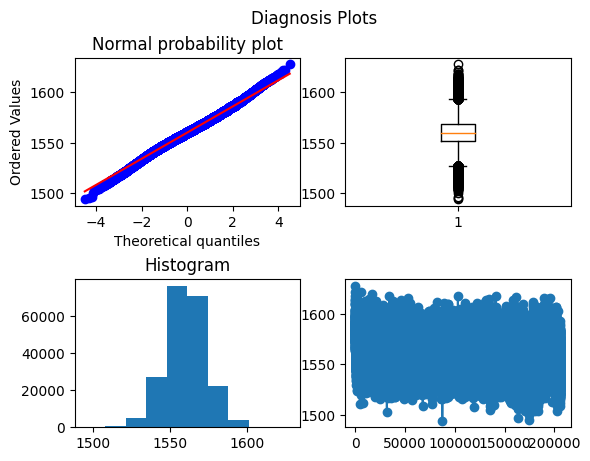

In [282]:
data_to_plot = single_layer_tracks['temp']
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

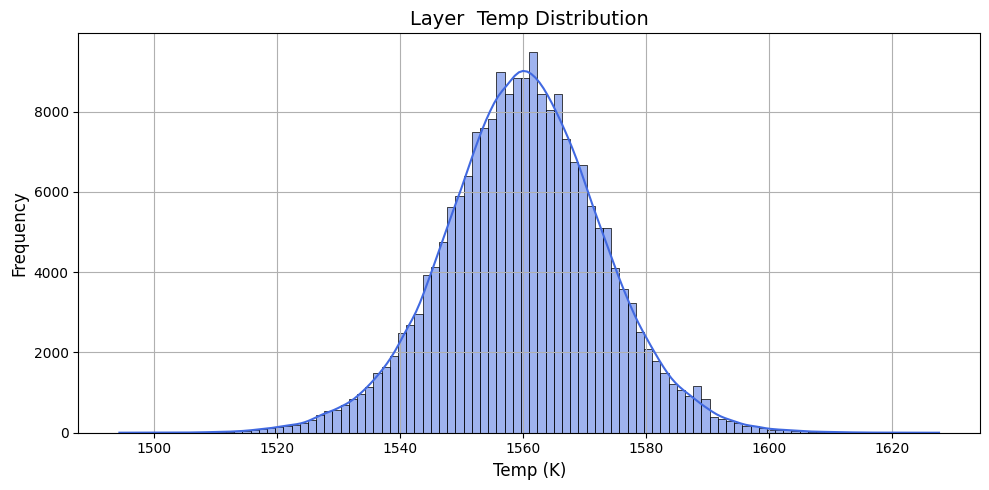

In [283]:
plt.figure(figsize=(10, 5))
sns.histplot(data_to_plot, bins=100, kde=True, color='royalblue')
plt.title("Layer  Temp Distribution", fontsize=14)
plt.xlabel("Temp (K)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [284]:
track_agg = single_layer_tracks.groupby('track_id')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
track_agg.describe()

,track_id,mean,std,min,max,median,count
count,130.0000,130.0000,130.0000,130.0000,130.0000,130.0000,130.0000
mean,64.5000,1560.0872,11.9241,1519.5877,1604.4862,1559.9827,1583.2231
std,37.6718,6.0982,1.5479,9.4825,8.3053,6.0681,373.7161
min,0.0000,1542.4776,9.4352,1494.4000,1565.9000,1541.0000,75.0000
25%,32.2500,1556.4893,10.9313,1514.8500,1599.6250,1556.5500,1720.0000
50%,64.5000,1560.1697,11.5120,1520.2500,1604.5000,1560.1000,1721.0000
75%,96.7500,1563.7398,12.3365,1525.6500,1609.8000,1563.5000,1721.0000
max,129.0000,1590.2720,17.2151,1566.0000,1627.6000,1588.9000,1721.0000


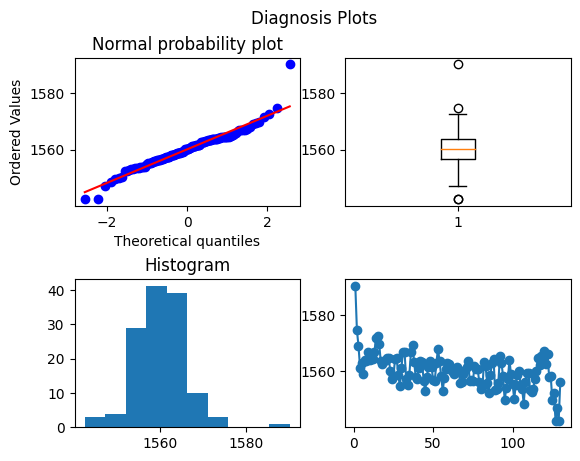

In [285]:
data_to_plot = track_agg["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

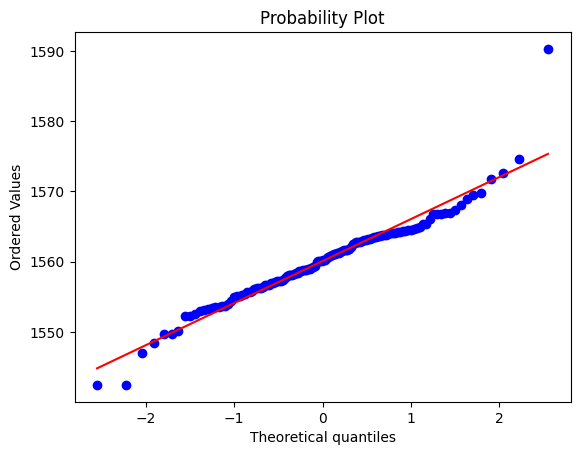

Shapiro-wilk test statistic = 0.946
Shapiro-wilk test p-value = 0.000
Runs test statistic = -5.277
Runs test p-value = 0.000



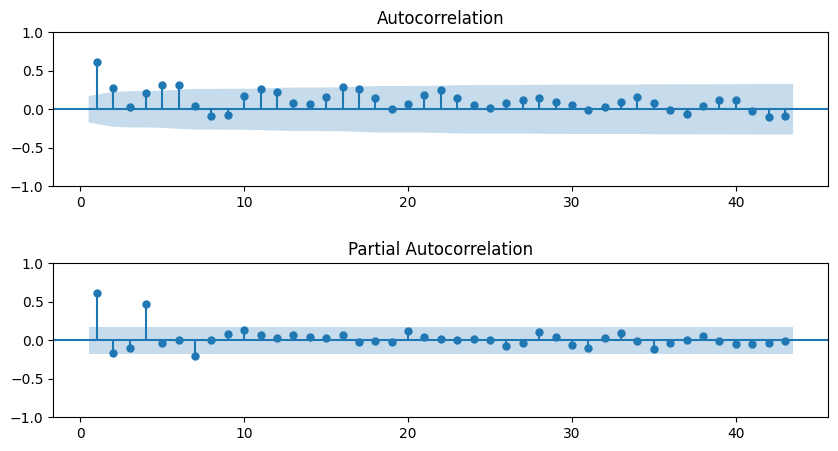

In [286]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

It's almost normally distributed, but there are strong outliers. Let's see which tracks stand as outliers

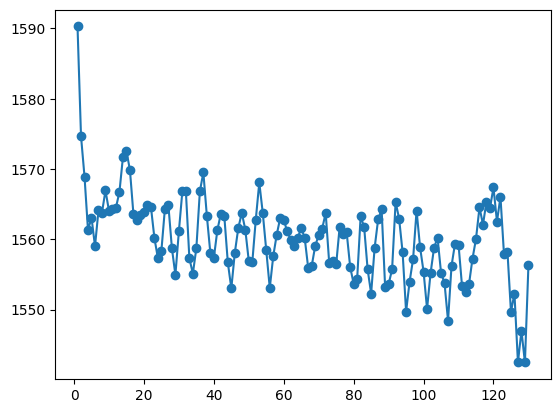

In [287]:
plt.plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

It is clear that initial and ending tracks cause the problems. The explanation from first phase still applies: First and last few tracks don't have much data in them. Let's remove them

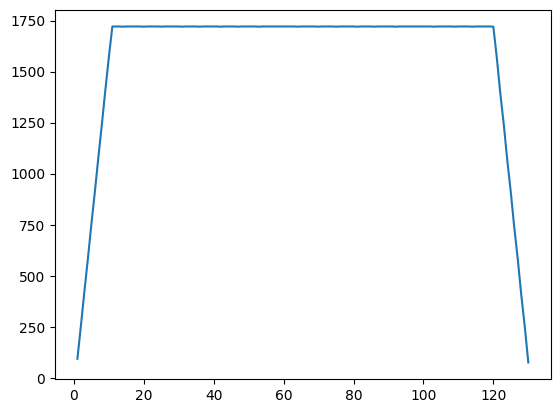

count     130.0000
mean     1583.2231
std       373.7161
min        75.0000
25%      1720.0000
50%      1721.0000
75%      1721.0000
max      1721.0000
Name: count, dtype: float64

In [288]:
plt.plot(np.arange(1, len(data_to_plot)+1), track_agg["count"])
plt.show()
track_agg["count"].describe()

In [289]:
lb = track_agg["count"].mean() * 0.2
track_agg_cleaned = track_agg[track_agg["count"] >= lb].reset_index()

print("The # of rows dropped =", track_agg["mean"].count()-track_agg_cleaned["mean"].count() )
track_agg_cleaned.describe()

The # of rows dropped = 4


,index,track_id,mean,std,min,max,median,count
count,126.0000,126.0000,126.0000,126.0000,126.0000,126.0000,126.0000,126.0000
mean,64.5000,64.5000,1559.9020,11.9505,1519.0889,1604.6841,1559.7992,1628.1508
std,36.5171,36.5171,5.1729,1.5557,8.4156,7.1661,5.2263,278.8903
min,2.0000,2.0000,1542.4848,10.0404,1494.4000,1585.2000,1541.0000,404.0000
25%,33.2500,33.2500,1556.6793,10.9313,1514.8500,1600.9000,1556.5500,1720.0000
50%,64.5000,64.5000,1560.1697,11.5120,1520.2000,1604.5000,1560.1000,1721.0000
75%,95.7500,95.7500,1563.7114,12.3912,1525.3750,1609.7750,1563.5000,1721.0000
max,127.0000,127.0000,1572.5617,17.2151,1534.8000,1621.9000,1572.3000,1721.0000


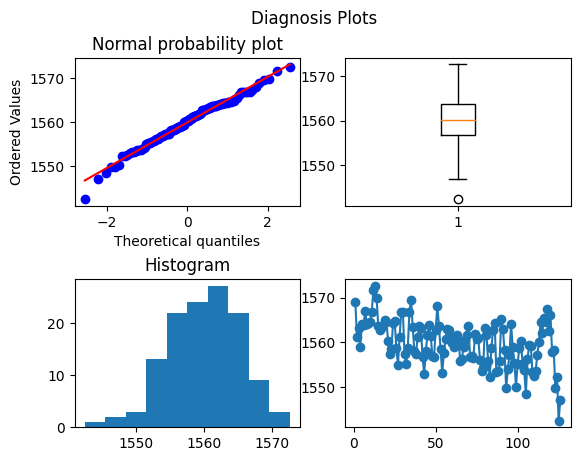

In [290]:
data_to_plot = track_agg_cleaned["mean"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

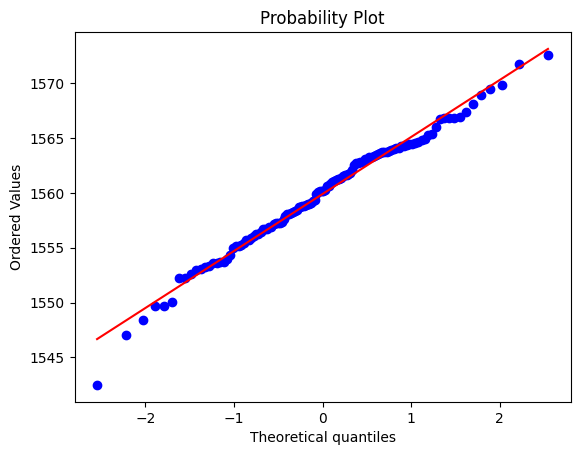

Shapiro-wilk test statistic = 0.989
Shapiro-wilk test p-value = 0.399
Runs test statistic = -4.984
Runs test p-value = 0.000



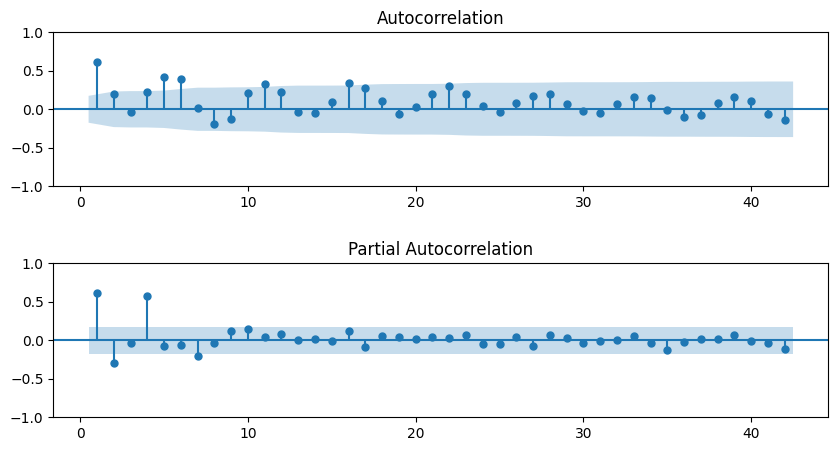

In [291]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

There are incredibly strong outliers that remain. No need to fix right now since ARIMA does not require normality.

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=3, d=1, q=0

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value    P-Value
ar.L1 -0.1254   0.0652  -1.9235 5.4417e-02
ar.L2 -0.1426   0.0537  -2.6538 7.9602e-03
ar.L3 -0.7829   0.0666 -11.7493 7.1170e-32

RESIDUAL SUM OF SQUARES
-------------------------
   DF       SS     MS
122.0 921.9361 7.5569

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square  P-Value
  12     28.4785   0.0047
  24     35.4903   0.0615
  36     44.1647   0.1648
  48     48.9063   0.4365
Runs test statistic = -0.881
Runs test p-value = 0.378



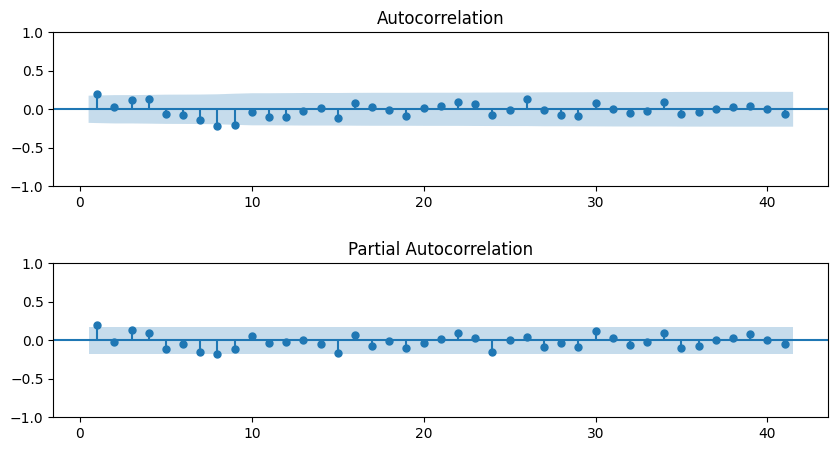

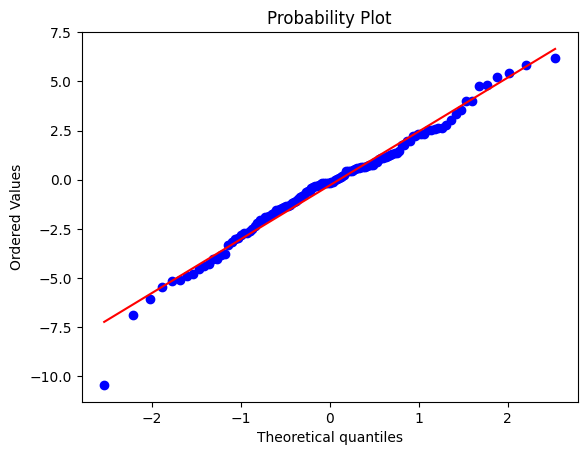

Shapiro-wilk test statistic = 0.982
Shapiro-wilk test p-value = 0.111


In [292]:
d = 1
model = qda.ARIMA(track_agg_cleaned["mean"], order=(3,d,0), add_constant=False)
qda.ARIMAsummary(model)
residuals = model.resid[d:].dropna()
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

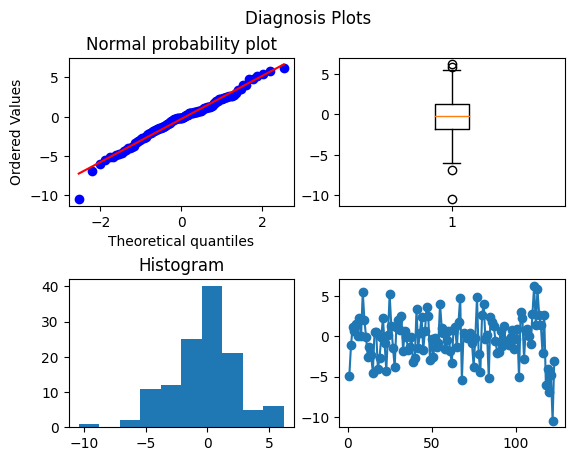

In [293]:
data_to_plot = residuals
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

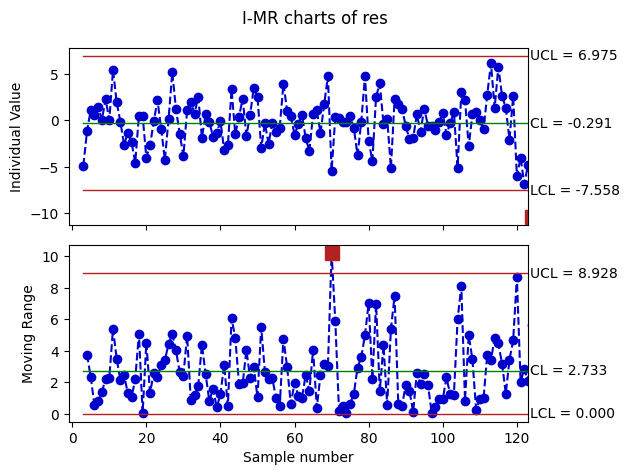

In [294]:
df_res = pd.DataFrame({'res': residuals})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

There seem to be some out of control values, which can be due to type 1 error,or assignable causes

- **Results**

The I-MR control chart for residuals from layer 726 showed a few points outside control limits. These may reflect Type I errors due to natural variation, or they may signal genuine assignable causes of instability. Diagnostic plots confirmed that the residuals maintained reasonable statistical properties, though the presence of mild outliers remains consistent with previous observations.

However, further inspection revealed a critical issue: the model identified in Approach 1 from Phase 1 does not work on the new data without substantial changes. To obtain a decent fit on layer 726, entirely different ARIMA parameters and coefficients are required. This violates the generalizability assumption central to Phase 2. As a result, while the method structure remains interpretable and the chart technically functions, its reliability collapses when applied to unseen layers.

In conclusion, generalizing this model for Phase 2 proves ineffective. Despite its previous success, the model lacks robustness under shifting process conditions, limiting its viability for real-time or cross-build deployment.

# Approach 2: Maximum Value for Each Track Across Adjacent Layers

- **Assumptions and Preliminary Data Analysis**

This approach validates the second model selected in Phase 1, where maximum temperature values from individual tracks (across multiple layers) are used for process monitoring. The assumption is that isolated high-temperature anomalies—possibly indicative of spatter or thermal build-up—can be captured using ARIMA-modeled residuals of maximum values per track.

The dataset includes all tracks up to layer 628, with each track uniquely identified via a composite key (layer_id * 10000 + track_id). For consistency, tracks with fewer than 20% of the average observation count were excluded to avoid skew from short or truncated tracks. Initial visual diagnostics of maximum temperatures revealed skewness and the presence of outliers.

An IQR-based filter was applied to remove extreme values beyond 1.5 IQR from the first and third quartiles. Post-cleaning diagnostic plots (histograms, boxplots, and Q-Q plots) showed clear improvement in distributional properties, with residuals closer to normality.

- **Proposed Methodology**

An ARIMA(1,0,2) model with a constant term was fitted to the cleaned sequence of maximum temperature values. This mirrors the model parameters used in Phase 1. Model diagnostics (independence and normality tests) were conducted on the raw residuals. To further enhance compliance with Shewhart assumptions, a Box-Cox transformation was applied to the residuals (shifted to avoid negative values), yielding a lambda value close to 1, indicating near-normal residual distribution.

After transformation, residuals satisfied both independence and normality assumptions, justifying the use of an I-MR control chart with ±3σ control limits. The control chart was then constructed on the transformed residuals without altering model structure or coefficients from Phase 1.





In [295]:
multi_layer_tracks = full_frame[full_frame["layer_id"]<=628] #change this to try for another track
multi_layer_tracks.describe()
multi_layer_tracks["layer_track"]  = multi_layer_tracks["layer_id"]*10000 + multi_layer_tracks["track_id"]
multi_layer_tracks_agg = multi_layer_tracks.groupby('layer_track')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
multi_layer_tracks_agg.describe()

,layer_track,mean,std,min,max,median,count
count,7.4400e+02,744.0000,744.0000,744.0000,744.0000,744.0000,744.0000
mean,6.2602e+06,1555.6612,12.6221,1517.3573,1603.5973,1554.9823,1388.2903
std,1.3344e+04,14.6174,2.6088,16.4495,20.0242,14.8980,599.5778
min,6.2400e+06,1513.9371,6.8143,1460.8984,1533.4860,1513.2967,4.0000
25%,6.2501e+06,1545.7201,10.8763,1506.8528,1593.8432,1544.6861,985.0000
50%,6.2601e+06,1556.6598,11.9198,1516.8668,1603.5102,1555.9552,1714.0000
75%,6.2701e+06,1565.3801,13.6314,1527.5903,1613.2213,1565.2806,1771.0000
max,6.2801e+06,1599.4531,23.7395,1579.7572,1689.7016,1599.4965,2424.0000


In [296]:
lb = multi_layer_tracks_agg["count"].mean() * 0.2
track_agg_ml_clean = multi_layer_tracks_agg[multi_layer_tracks_agg["count"] >= lb].reset_index()

print("The # of rows dropped =", multi_layer_tracks_agg["mean"].count()-track_agg_ml_clean["mean"].count() )
track_agg_ml_clean.describe()

The # of rows dropped = 65


,index,layer_track,mean,std,min,max,median,count
count,679.0000,6.7900e+02,679.0000,679.0000,679.0000,679.0000,679.0000,679.0000
mean,369.9028,6.2601e+06,1555.2856,12.8290,1515.8124,1605.2131,1554.5330,1509.9411
std,218.6941,1.3601e+04,13.1448,2.5674,14.4363,18.3842,13.4827,473.0713
min,1.0000,6.2400e+06,1516.5536,8.3561,1460.8984,1554.7498,1516.2741,281.0000
25%,178.5000,6.2501e+06,1546.0676,11.0301,1506.7122,1595.0620,1544.8080,1278.5000
50%,368.0000,6.2601e+06,1556.4074,12.0432,1516.5738,1603.9669,1555.6509,1714.0000
75%,559.5000,6.2701e+06,1564.7440,13.7969,1525.9347,1613.3335,1564.3934,1849.0000
max,742.0000,6.2801e+06,1583.7508,23.7395,1547.6338,1689.7016,1582.8100,2424.0000


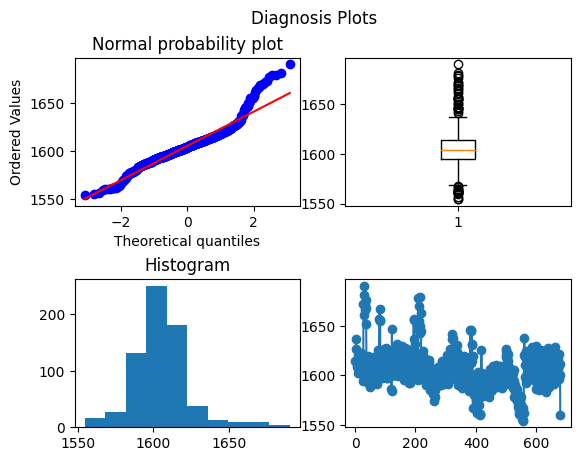

In [297]:
data_to_plot = track_agg_ml_clean["max"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

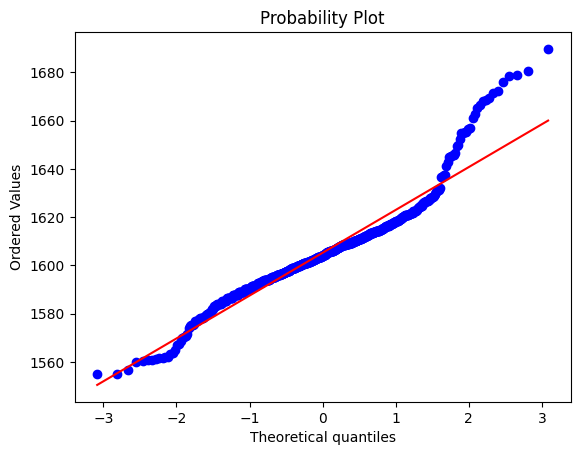

Shapiro-wilk test statistic = 0.929
Shapiro-wilk test p-value = 0.000
Runs test statistic = -9.687
Runs test p-value = 0.000



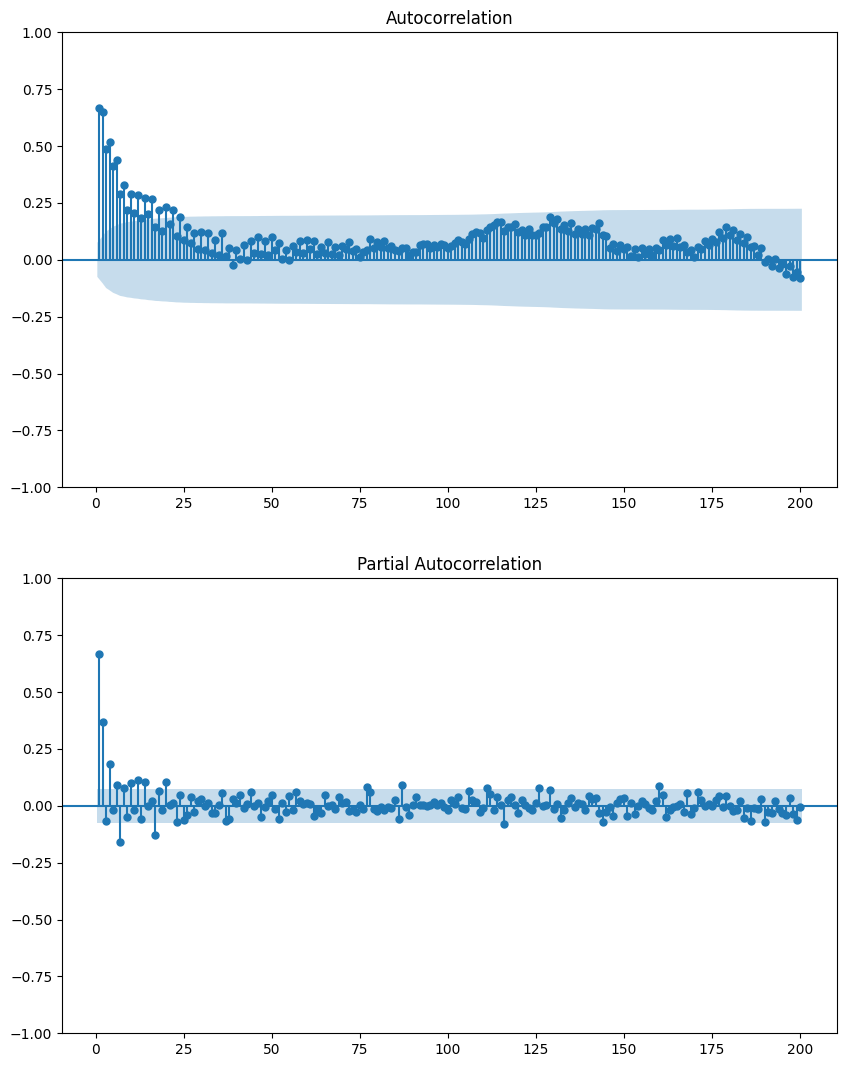

In [298]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

In [299]:
Q1 = track_agg_ml_clean['max'].quantile(0.25)
Q3 = track_agg_ml_clean['max'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

track_agg_ml_cleaner = track_agg_ml_clean[(track_agg_ml_clean['max'] > lower_bound) & 
                     (track_agg_ml_clean['max'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", track_agg_ml_clean["mean"].count()-track_agg_ml_cleaner["mean"].count() )

The # of rows dropped = 48


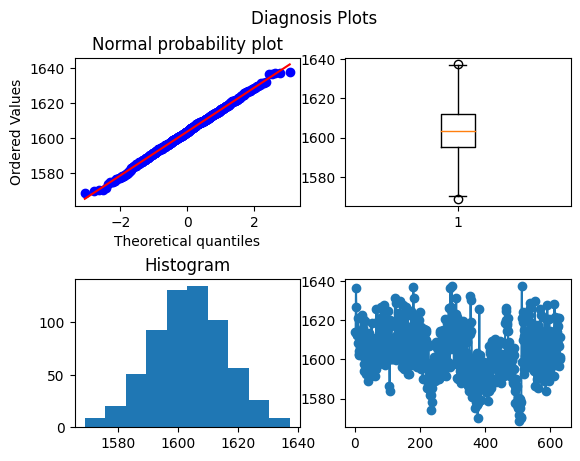

In [300]:
data_to_plot = track_agg_ml_cleaner["max"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

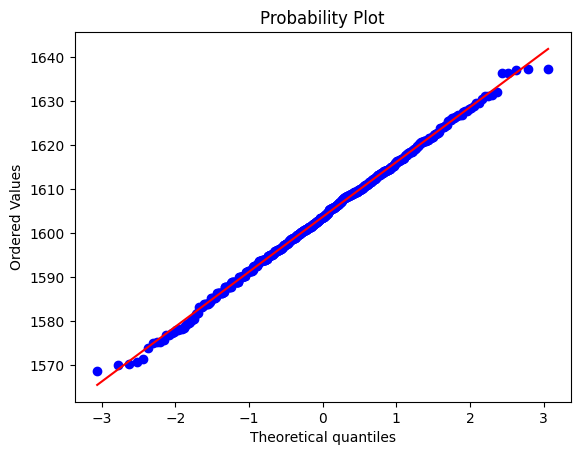

Shapiro-wilk test statistic = 0.998
Shapiro-wilk test p-value = 0.721
Runs test statistic = -7.609
Runs test p-value = 0.000



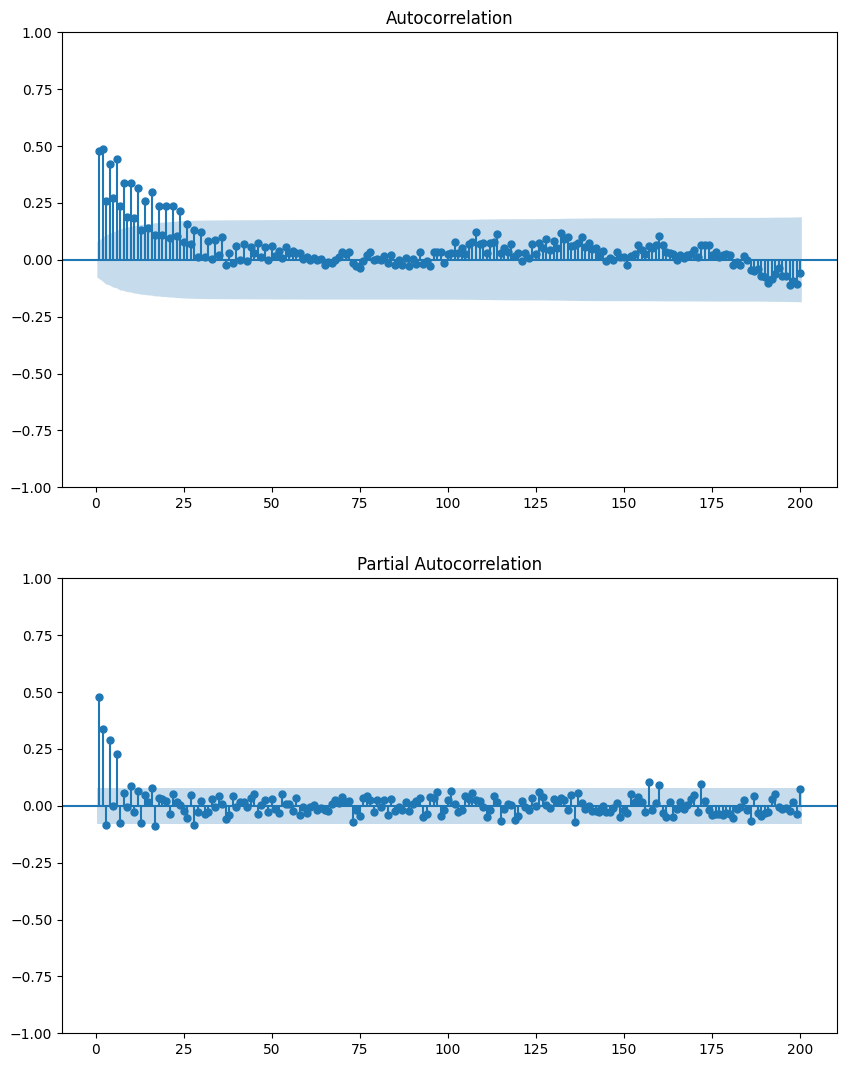

In [301]:
_ = qda.Assumptions(data_to_plot).normality()
_ = qda.Assumptions(data_to_plot).independence()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=1, d=0, q=2

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term      Coef  SE Coef  T-Value    P-Value
const 1604.0542   2.0226 793.0538 0.0000e+00
ar.L1    0.9380   0.0193  48.6095 0.0000e+00
ma.L1   -0.6759   0.0367 -18.4373 6.5940e-76
ma.L2   -0.0258   0.0394  -0.6548 5.1258e-01

RESIDUAL SUM OF SQUARES
-------------------------
   DF         SS       MS
627.0 66374.2608 105.8601

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12    195.8741 2.3149e-35
  24    358.4683 2.3627e-61
  36    428.0054 1.4508e-68
  48    461.7633 5.2503e-69
Runs test statistic = -0.047
Runs test p-value = 0.962



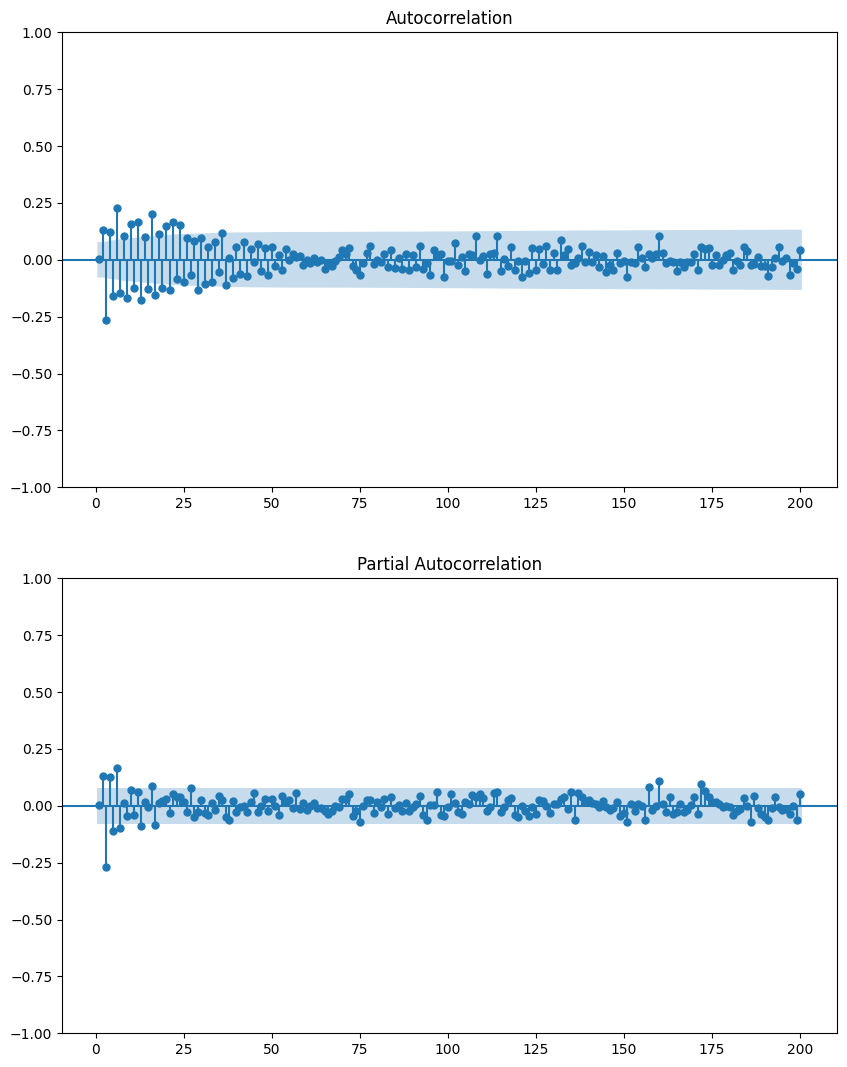

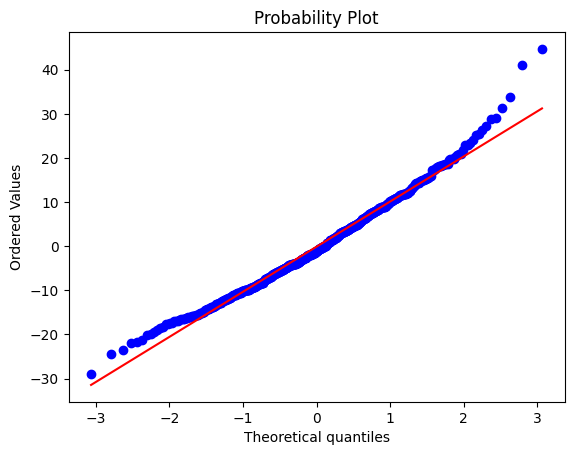

Shapiro-wilk test statistic = 0.986
Shapiro-wilk test p-value = 0.000


In [302]:
d = 0
model = qda.ARIMA(track_agg_ml_cleaner["max"], order=(1,d,2), add_constant=True)
qda.ARIMAsummary(model)
p2_residuals = model.resid[d:].dropna()
_ = qda.Assumptions(p2_residuals).independence()
_ = qda.Assumptions(p2_residuals).normality()

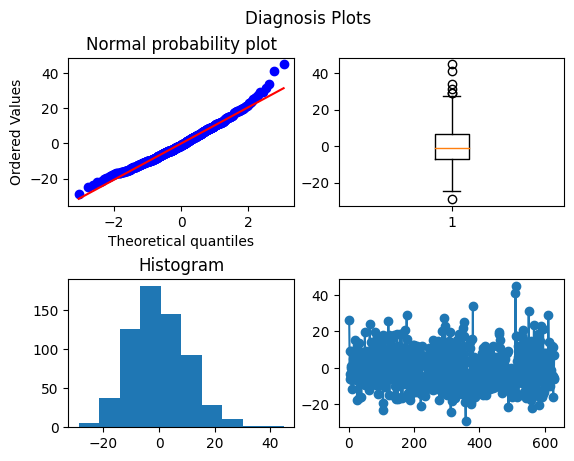

In [303]:
data_to_plot = p2_residuals.dropna()
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

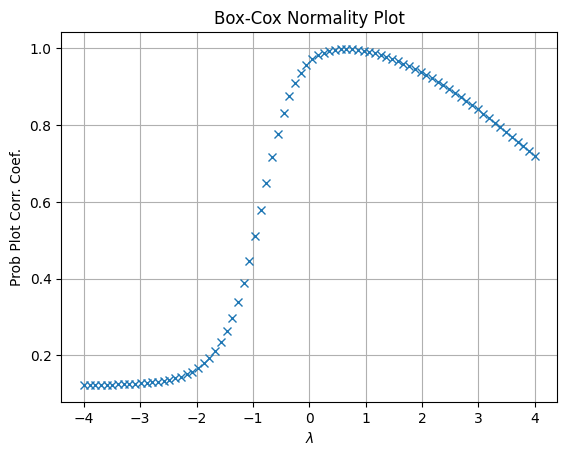

In [304]:
fig = plt.figure()
ax = fig.add_subplot(111)
stats.boxcox_normplot(p2_residuals+30, -4, 4, plot=ax)
# add grid
ax.grid(True)

In [305]:
[data_BC, lmbda] = stats.boxcox(p2_residuals+30)
print("Lambda =",lmbda)

Lambda = 0.6251457309967081


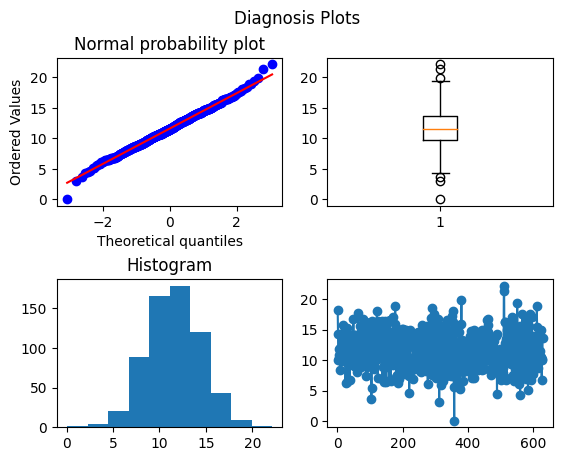

In [306]:
data_to_plot = data_BC
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\qdatoolkit\models.py:723: UserWarning: A numpy array was passed to the Assumptions class and converted to Pandas Series.
Note that all other methods in qda-toolkit only accept Pandas Series or Pandas Dataframe.
  warnings.warn(


Runs test statistic = -0.189
Runs test p-value = 0.850



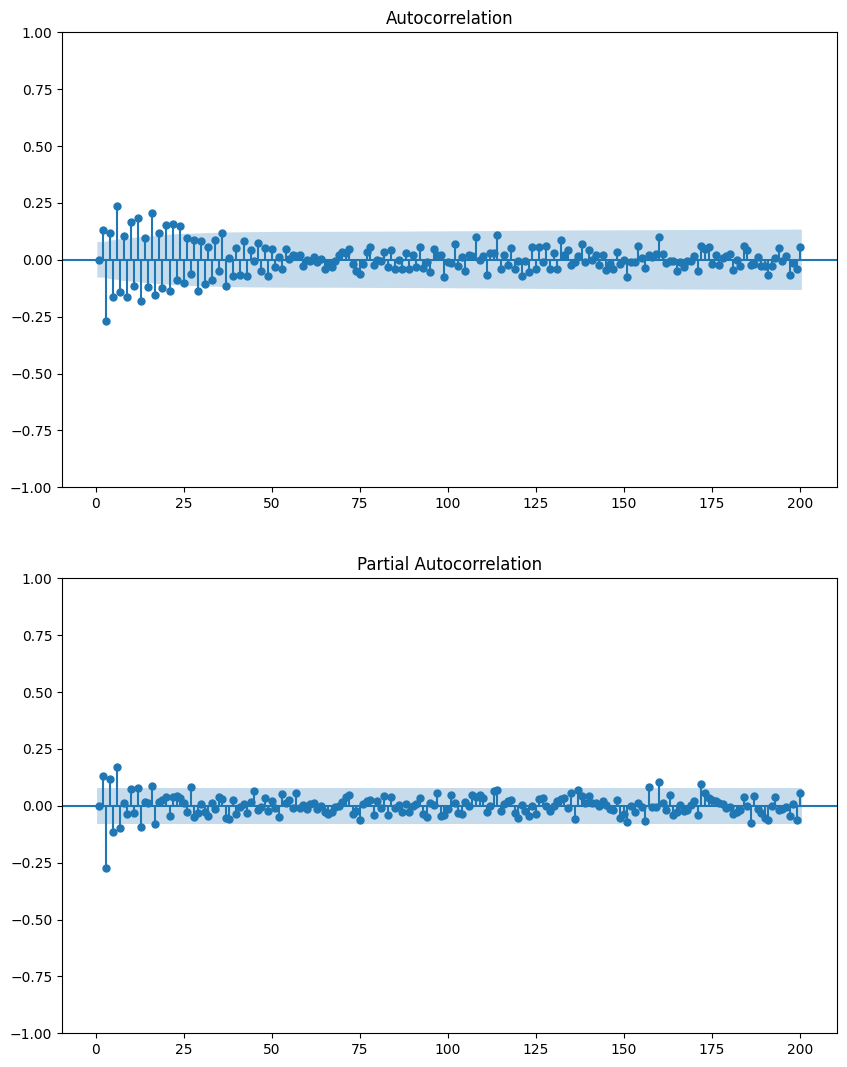

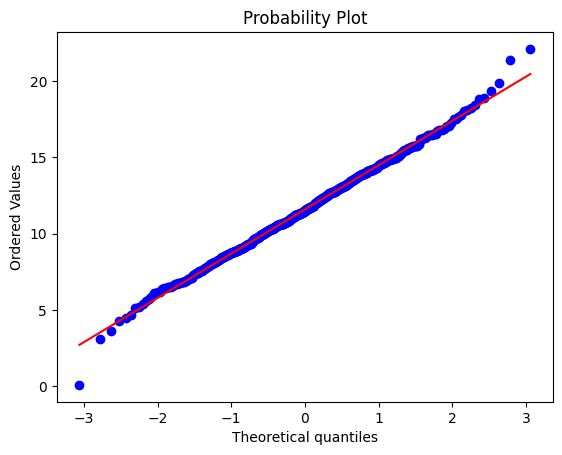

Shapiro-wilk test statistic = 0.998
Shapiro-wilk test p-value = 0.506


In [307]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

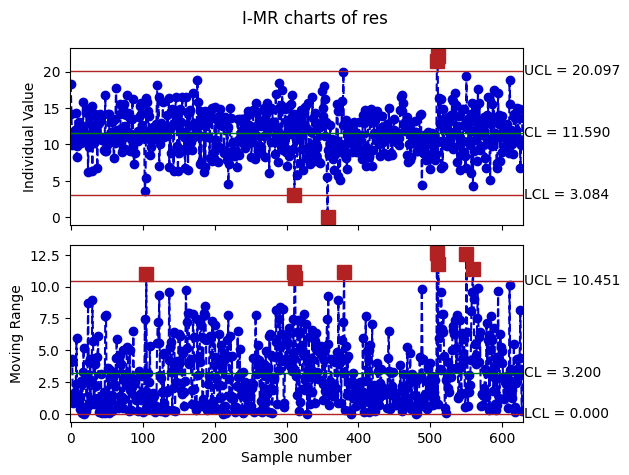

In [308]:
df_res = pd.DataFrame({'res': data_BC})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

We can see that the same approach as phase one, with same ARIMA variables are working as they should. However,it does not confirm that the charts in phase 1 are useful yet. We will try to confirm their usefulness step by step.

## Using same box-cox transformation on residuals as phase 1

In phase 1, we used a shift of 25 to get all values positive. But a shift of 25 is not enough to make everything positive in this case. So, let us try to adjust the model in phase 1 first.

Import data of phase 1:

In [309]:
all_layers = {}
i = 224
j= 1
while i <= 573:
    layer_name = 'layer_'+str(i)
    layer = pd.read_csv('Data/'+layer_name+'.csv')
    all_layers[layer_name] = layer
    if i < 528:
        if i%10 == 8:
            i += 96
            j+=1
        else:
            i+=1
    elif i == 528:
        i = 569
    else:
        i += 1
for i in all_layers:
    if i =="layer_224":
        p1_full_frame = all_layers[i]
    else:
        p1_full_frame = pd.concat([p1_full_frame,all_layers[i]])
p1_full_frame = p1_full_frame.reset_index().drop(['index'], axis=1)

In [310]:
p1_multi_layer_tracks = p1_full_frame[p1_full_frame["layer_id"]<=228] #change this to try for another track
p1_multi_layer_tracks.describe()
p1_multi_layer_tracks["layer_track"]  = p1_multi_layer_tracks["layer_id"]*10000 + p1_multi_layer_tracks["track_id"]
p1_multi_layer_tracks_agg = p1_multi_layer_tracks.groupby('layer_track')['temp'].agg([
    'mean', 'std', 'min', 'max', 'median', 'count']).reset_index()
p1_multi_layer_tracks_agg.describe()

,layer_track,mean,std,min,max,median,count
count,7.4300e+02,743.0000,743.0000,743.0000,743.0000,743.0000,743.0000
mean,2.2602e+06,1555.1023,12.7250,1516.8888,1601.0727,1554.3964,1218.8452
std,1.3338e+04,14.1778,3.6213,17.4635,14.9817,14.8030,522.6786
min,2.2400e+06,1504.6334,6.0492,1444.2000,1548.2000,1494.3000,8.0000
25%,2.2501e+06,1546.3816,10.9188,1508.3500,1593.6500,1545.6750,875.5000
50%,2.2601e+06,1556.3601,11.9021,1517.5000,1602.9000,1555.6500,1500.0000
75%,2.2701e+06,1564.7240,13.2051,1527.4000,1610.7500,1564.3250,1556.5000
max,2.2801e+06,1595.6682,34.8920,1580.8000,1639.1000,1595.5500,2122.0000


In [311]:
lb = p1_multi_layer_tracks_agg["count"].mean() * 0.2
p1_track_agg_ml_clean = p1_multi_layer_tracks_agg[p1_multi_layer_tracks_agg["count"] >= lb].reset_index()

print("The # of rows dropped =", p1_multi_layer_tracks_agg["mean"].count()-p1_track_agg_ml_clean["mean"].count() )
p1_track_agg_ml_clean.describe()

The # of rows dropped = 64


,index,layer_track,mean,std,min,max,median,count
count,679.0000,6.7900e+02,679.0000,679.0000,679.0000,679.0000,679.0000,679.0000
mean,369.2283,2.2601e+06,1554.5365,12.9360,1515.2809,1602.2968,1553.7702,1323.6200
std,218.5488,1.3601e+04,13.1829,3.6822,15.8824,13.3926,13.8800,413.4567
min,1.0000,2.2400e+06,1504.6334,8.3939,1444.2000,1548.2000,1494.3000,246.0000
25%,177.5000,2.2501e+06,1546.6127,11.0918,1507.8000,1595.0000,1545.8500,1122.5000
50%,368.0000,2.2601e+06,1556.2625,12.0670,1517.0000,1603.4000,1555.5000,1500.0000
75%,558.5000,2.2701e+06,1564.3175,13.3956,1526.2000,1610.8500,1563.9500,1617.0000
max,741.0000,2.2801e+06,1582.4782,34.8920,1547.3000,1639.1000,1581.7000,2122.0000


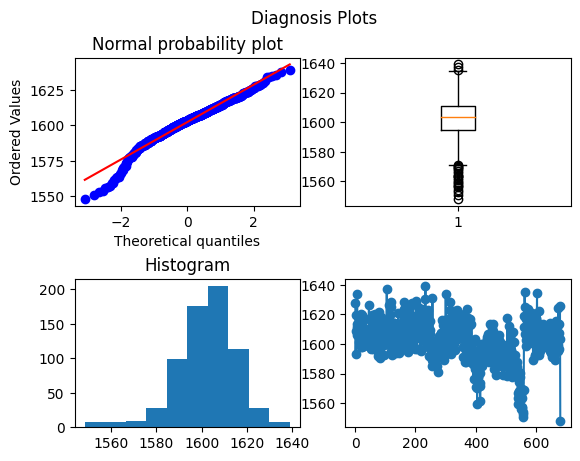

In [312]:
data_to_plot = p1_track_agg_ml_clean["max"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

In [313]:
Q1 = p1_track_agg_ml_clean['max'].quantile(0.25)
Q3 = p1_track_agg_ml_clean['max'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

p1_track_agg_ml_cleaner = p1_track_agg_ml_clean[(p1_track_agg_ml_clean['max'] > lower_bound) & 
                     (p1_track_agg_ml_clean['max'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", p1_track_agg_ml_clean["mean"].count()-p1_track_agg_ml_cleaner["mean"].count() )

The # of rows dropped = 24


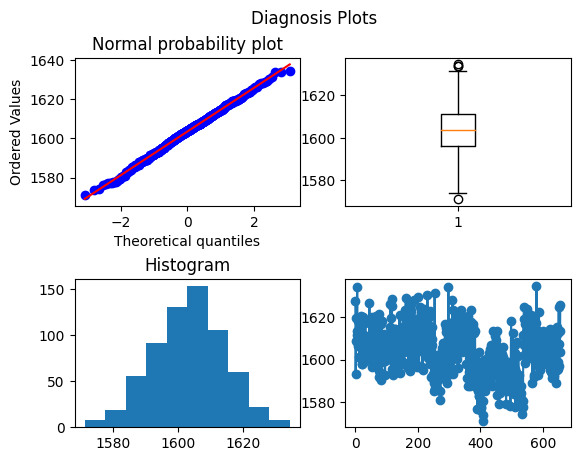

In [314]:
data_to_plot = p1_track_agg_ml_cleaner["max"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=1, d=0, q=2

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term      Coef  SE Coef  T-Value    P-Value
const 1604.1668   2.2841 702.3234 0.0000e+00
ar.L1    0.9726   0.0111  87.4027 0.0000e+00
ma.L1   -0.7263   0.0365 -19.9225 2.5987e-88
ma.L2   -0.0758   0.0378  -2.0062 4.4835e-02

RESIDUAL SUM OF SQUARES
-------------------------
   DF         SS      MS
651.0 51526.8583 79.1503

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12    134.1474 9.0561e-23
  24    204.4346 1.4457e-30
  36    234.5321 5.8098e-31
  48    258.0370 1.5307e-30
Runs test statistic = -0.881
Runs test p-value = 0.378



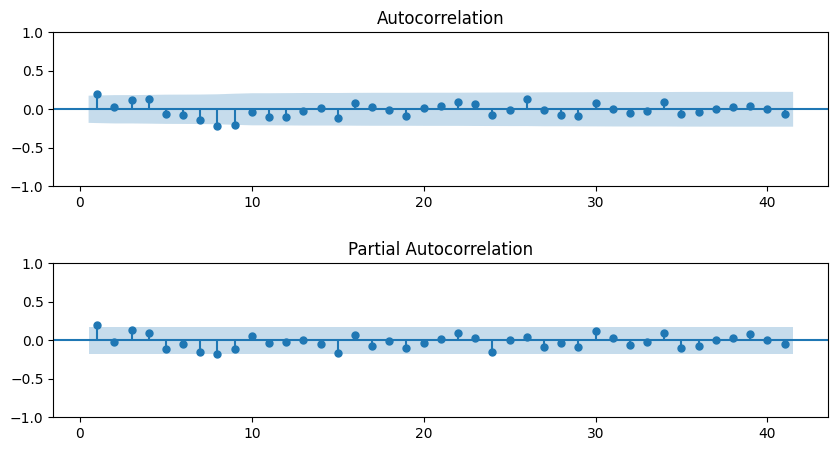

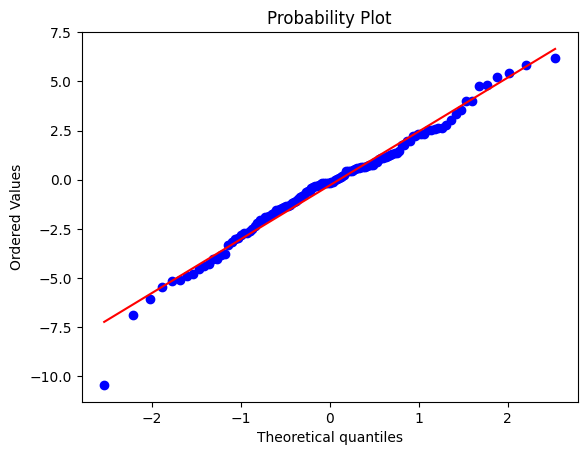

Shapiro-wilk test statistic = 0.982
Shapiro-wilk test p-value = 0.111


In [315]:
d = 0
model = qda.ARIMA(p1_track_agg_ml_cleaner["max"], order=(1,d,2), add_constant=True)
qda.ARIMAsummary(model)
p1_residuals = model.resid[d:].dropna()
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

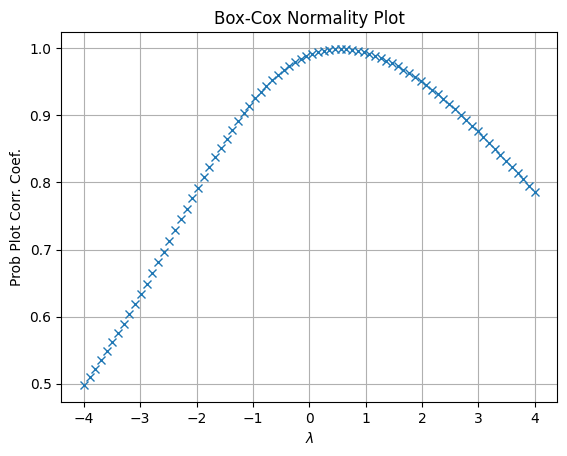

In [316]:
fig = plt.figure()
ax = fig.add_subplot(111)
stats.boxcox_normplot(p1_residuals+30, -4, 4, plot=ax)
# add grid
ax.grid(True)

In [317]:
[p1_data_BC, lmbda] = stats.boxcox(p1_residuals+30)
print("Lambda =",lmbda)

Lambda = 0.540631275623144


Let's choose 0.55 for simplicity and readability

In [318]:
p1_data_BC= stats.boxcox(p1_residuals+30,lmbda=0.55)

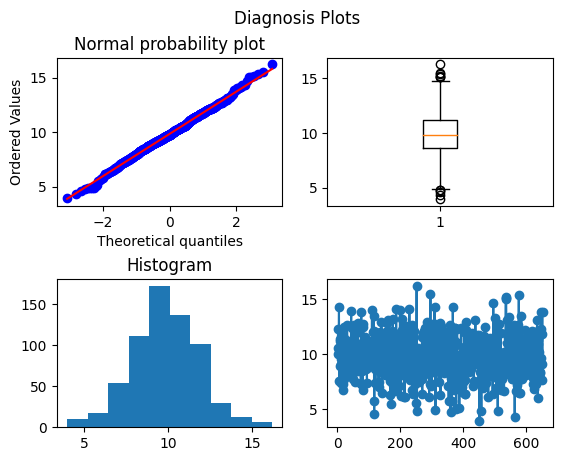

In [319]:
data_to_plot = p1_data_BC
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\qdatoolkit\models.py:723: UserWarning: A numpy array was passed to the Assumptions class and converted to Pandas Series.
Note that all other methods in qda-toolkit only accept Pandas Series or Pandas Dataframe.
  warnings.warn(


Runs test statistic = -0.640
Runs test p-value = 0.522



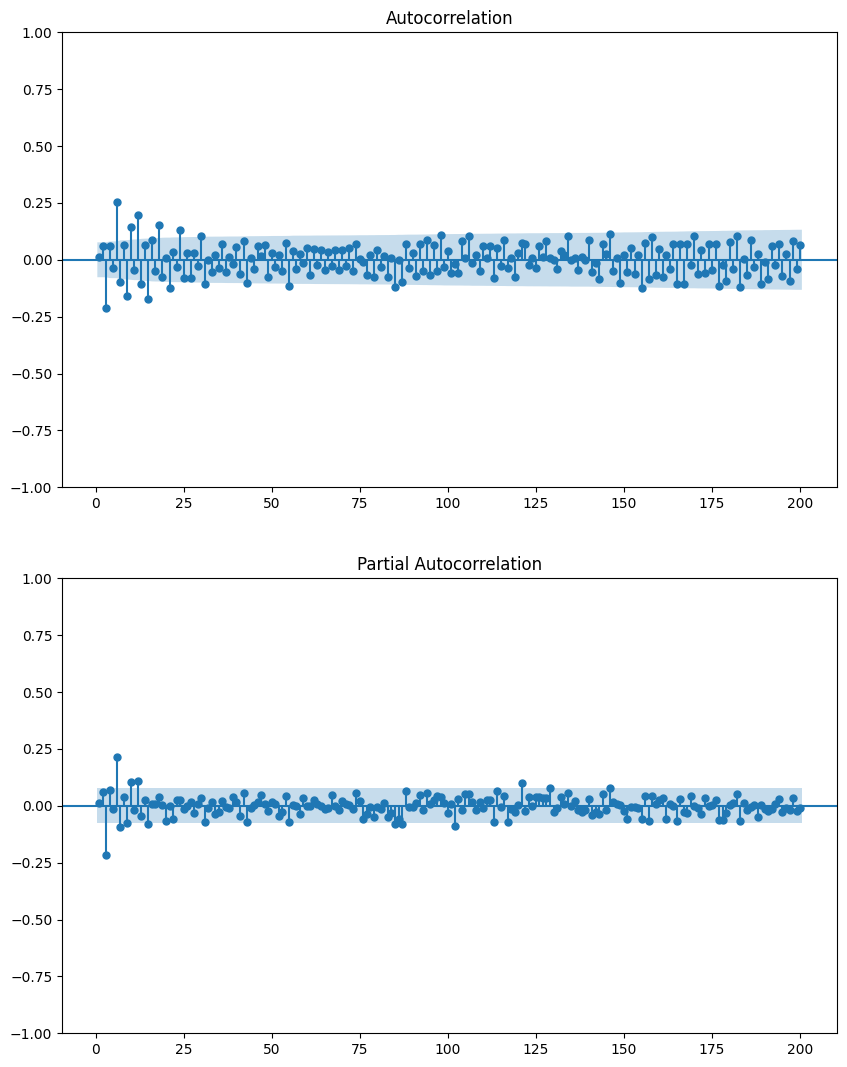

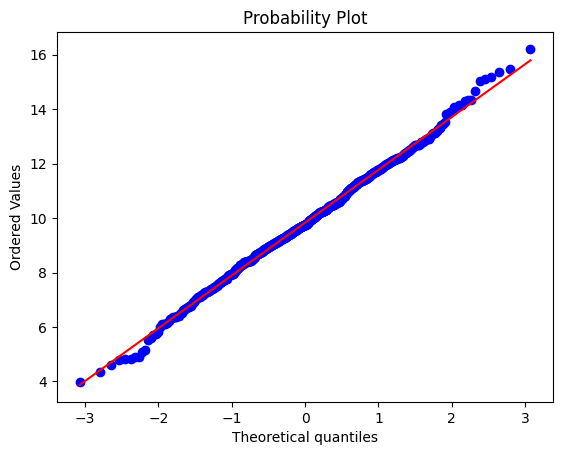

Shapiro-wilk test statistic = 0.998
Shapiro-wilk test p-value = 0.456


In [320]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

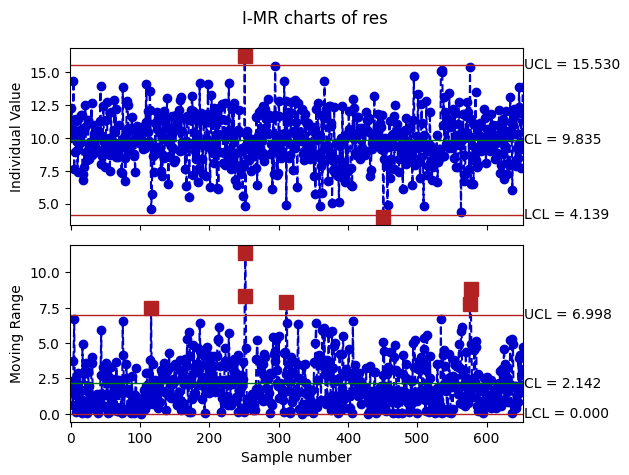

In [321]:
df_res = pd.DataFrame({'res': p1_data_BC})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

Let's assume no assignable cause, use these charts

If we transform the residuals from phase two using sam transformation:

In [322]:
p2_data_BC = stats.boxcox(p2_residuals+30,lmbda =0.55)


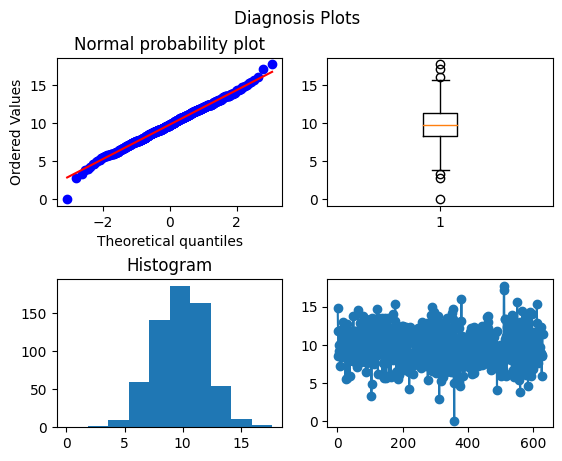

In [323]:
data_to_plot = p2_data_BC
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\qdatoolkit\models.py:723: UserWarning: A numpy array was passed to the Assumptions class and converted to Pandas Series.
Note that all other methods in qda-toolkit only accept Pandas Series or Pandas Dataframe.
  warnings.warn(


Runs test statistic = -0.037
Runs test p-value = 0.971



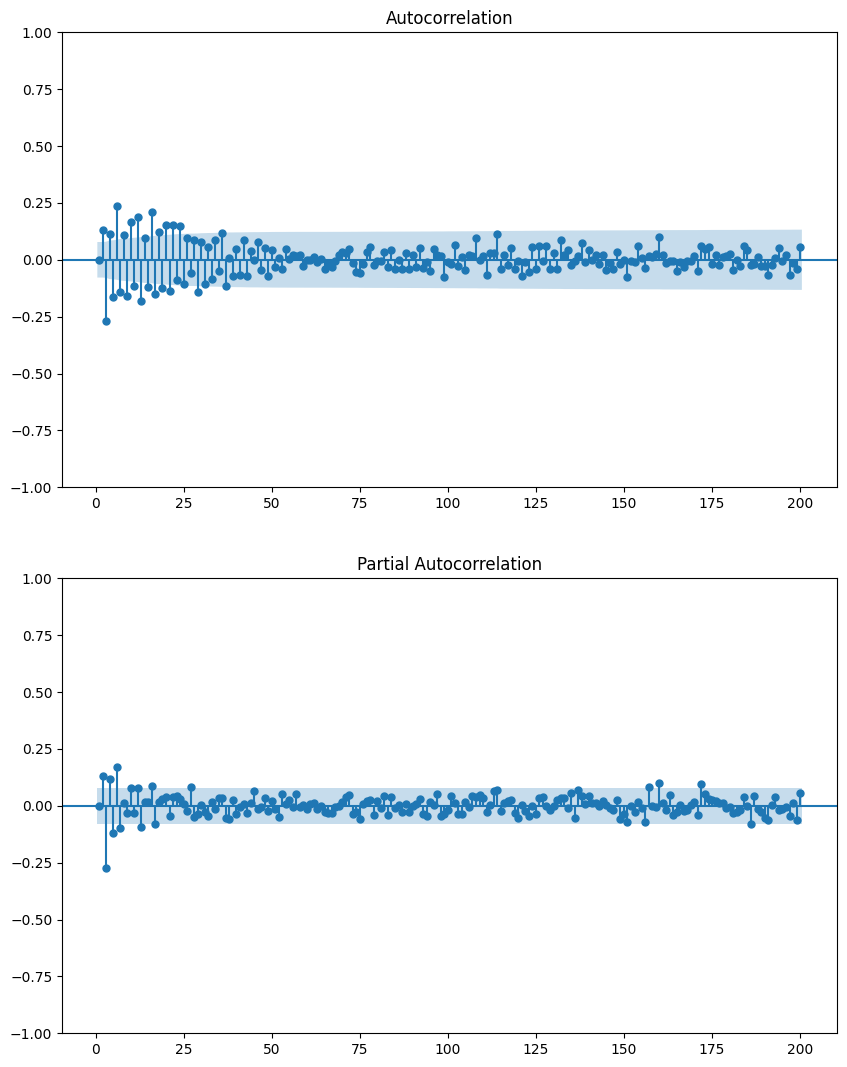

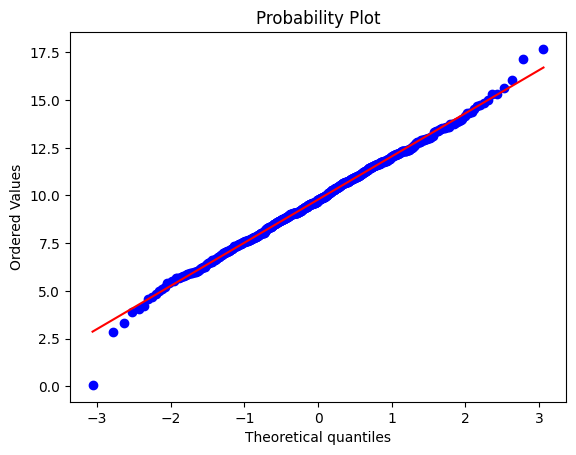

Shapiro-wilk test statistic = 0.997
Shapiro-wilk test p-value = 0.297


In [324]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

The transformation works well enough! If we construct the charts with these residuals from scratch:

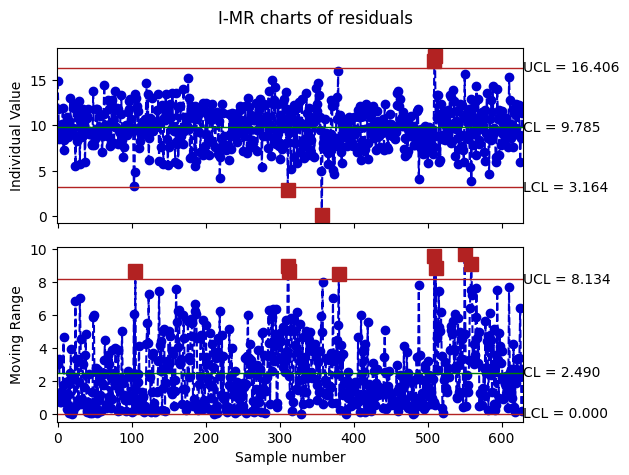

In [325]:
df_res = pd.DataFrame({'residuals': p2_data_BC})
df_res= qda.ControlCharts.IMR(df_res, 'residuals',K=3)

We can see limits are similar, but not quite same. Lets use the exact limits used in phase 1 in construction of new charts instead to see how they hold up:

In [326]:
df_res2 = df_res[["residuals","I_UCL","I_CL","I_LCL","MR","MR_UCL","MR_CL","MR_LCL"]]

In [327]:
df_res2["I_CL"] = 9.835
df_res2["I_UCL"] = 15.530
df_res2["I_LCL"] = 4.139
df_res2["MR_CL"] = 2.142
df_res2["MR_UCL"] = 6.998
df_res2["MR_LCL"] = 0
df_res2['I_TEST1'] = np.where((df_res2["residuals"] > df_res2['I_UCL']) | (df_res2["residuals"] < df_res2['I_LCL']), df_res2["residuals"], np.nan)
df_res2['MR_TEST1'] = np.where((df_res2['MR'] > df_res2['MR_UCL']) | (df_res2['MR'] < df_res2['MR_LCL']), df_res2['MR'], np.nan)

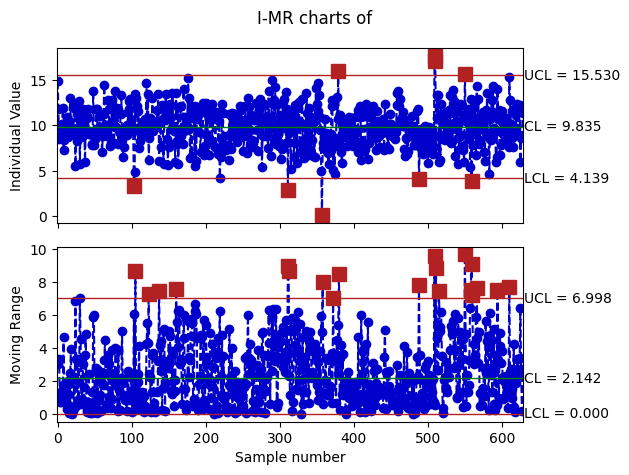

In [328]:
            # Plot the I and MR charts
            fig, ax = plt.subplots(2, 1, sharex=True)
            fig.suptitle(('I-MR charts of'))
            ax[0].plot(df_res2['residuals'], color='mediumblue', linestyle='--', marker='o')
            ax[0].plot(df_res2['I_UCL'], color='firebrick', linewidth=1)
            ax[0].plot(df_res2['I_CL'], color='g', linewidth=1)
            ax[0].plot(df_res2['I_LCL'], color='firebrick', linewidth=1)
            ax[0].set_ylabel('Individual Value')
            ax[1].set_xlabel('Sample number')
            # add the values of the control limits on the right side of the plot
            ax[0].text(len(df_res2)+.5, df_res2['I_UCL'].iloc[0], 'UCL = {:.3f}'.format(df_res2['I_UCL'].iloc[0]), verticalalignment='center')
            ax[0].text(len(df_res2)+.5, df_res2['I_CL'].iloc[0], 'CL = {:.3f}'.format(df_res2['I_CL'].iloc[0]), verticalalignment='center')
            ax[0].text(len(df_res2)+.5, df_res2['I_LCL'].iloc[0], 'LCL = {:.3f}'.format(df_res2['I_LCL'].iloc[0]), verticalalignment='center')
            # highlight the points that violate the alarm rules
            ax[0].plot(df_res2['I_TEST1'], linestyle='none', marker='s', color='firebrick', markersize=10)
            ax[0].set_xlim(-1, len(df_res2))

            ax[1].plot(df_res2['MR'], color='mediumblue', linestyle='--', marker='o')
            ax[1].plot(df_res2['MR_UCL'], color='firebrick', linewidth=1)
            ax[1].plot(df_res2['MR_CL'], color='g', linewidth=1)
            ax[1].plot(df_res2['MR_LCL'], color='firebrick', linewidth=1)
            ax[1].set_ylabel('Moving Range')
            ax[1].set_xlabel('Sample number')
            # add the values of the control limits on the right side of the plot
            ax[1].text(len(df_res2)+.5, df_res2['MR_UCL'].iloc[0], 'UCL = {:.3f}'.format(df_res2['MR_UCL'].iloc[0]), verticalalignment='center')
            ax[1].text(len(df_res2)+.5, df_res2['MR_CL'].iloc[0], 'CL = {:.3f}'.format(df_res2['MR_CL'].iloc[0]), verticalalignment='center')
            ax[1].text(len(df_res2)+.5, df_res2['MR_LCL'].iloc[0], 'LCL = {:.3f}'.format(df_res2['MR_LCL'].iloc[0]), verticalalignment='center')
            # highlight the points that violate the alarm rules
            ax[1].plot(df_res2['MR_TEST1'], linestyle='none', marker='s', color='firebrick', markersize=10)
            ax[1].set_xlim(-1, len(df_res2))
            # set the x-axis limits
            ax[1].set_xlim(-1, len(df_res2))
            plt.tight_layout()
            plt.show()

There seems to be many out of control points, especially in MR charts.

## Using same arima coefficients as well, not just the same transformation

Let's remember the coefficients of arima in stage 1:

In [329]:
d = 0
model = qda.ARIMA(p1_track_agg_ml_cleaner["max"], order=(1,d,2), add_constant=True)
qda.ARIMAsummary(model)
p1_residuals = model.resid[d:].dropna()


---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=1, d=0, q=2

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term      Coef  SE Coef  T-Value    P-Value
const 1604.1668   2.2841 702.3234 0.0000e+00
ar.L1    0.9726   0.0111  87.4027 0.0000e+00
ma.L1   -0.7263   0.0365 -19.9225 2.5987e-88
ma.L2   -0.0758   0.0378  -2.0062 4.4835e-02

RESIDUAL SUM OF SQUARES
-------------------------
   DF         SS      MS
651.0 51526.8583 79.1503

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12    134.1474 9.0561e-23
  24    204.4346 1.4457e-30
  36    234.5321 5.8098e-31
  48    258.0370 1.5307e-30


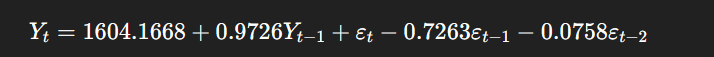

Let us calculate the new residuals on old model, without fitting a new model

In [330]:
predictions = model.predict(end = 630)
p2_residuals_2 = track_agg_ml_cleaner["max"] - predictions
p2_residuals_2 = p2_residuals_2.dropna()

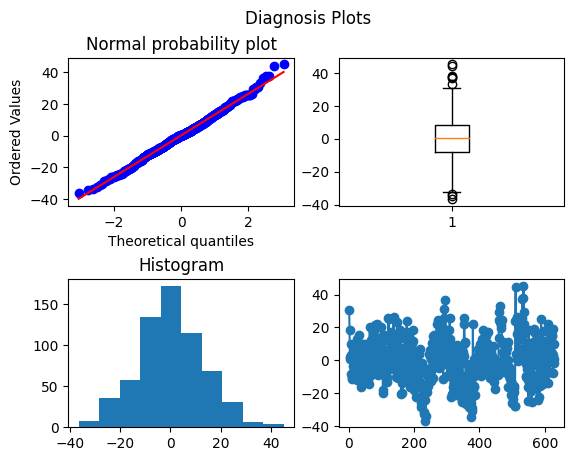

In [331]:
data_to_plot = p2_residuals_2
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = -6.903
Runs test p-value = 0.000



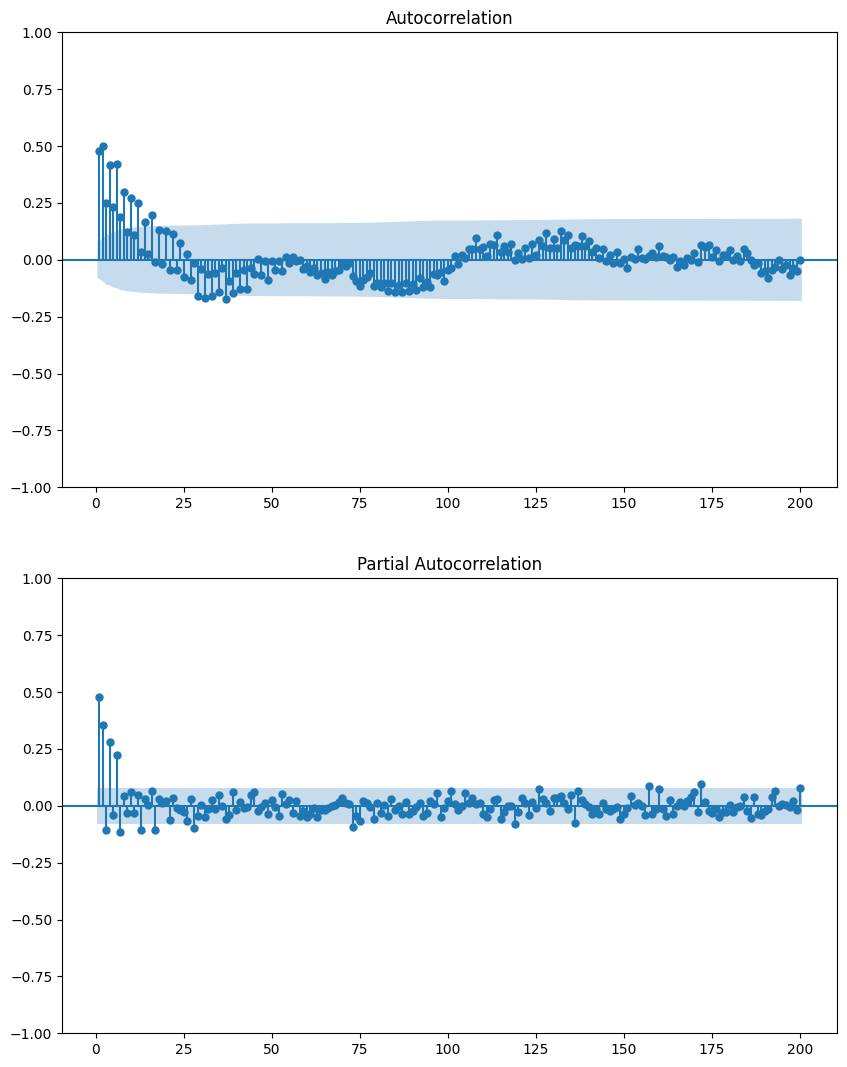

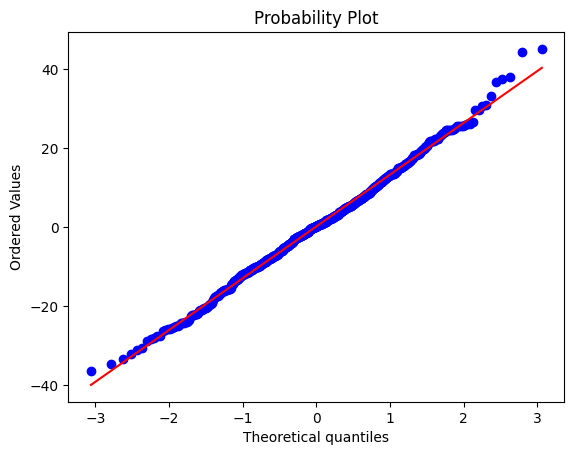

Shapiro-wilk test statistic = 0.997
Shapiro-wilk test p-value = 0.252


In [332]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

In [333]:
[data_BC, lmbda] = stats.boxcox(p2_residuals_2+40)
print("Lambda =",lmbda)

Lambda = 0.9053536600734086


+30 is not enough of a shift for this, let's try fitting the phase one with + 40

In [334]:
[p1_data_BC, lmbda] = stats.boxcox(p1_residuals+40)
print("Lambda =",lmbda)

Lambda = 0.35869458908133417


Let's go with 0.36

In [335]:
p1_data_BC_2 = stats.boxcox(p1_residuals+40,lmbda=0.36)

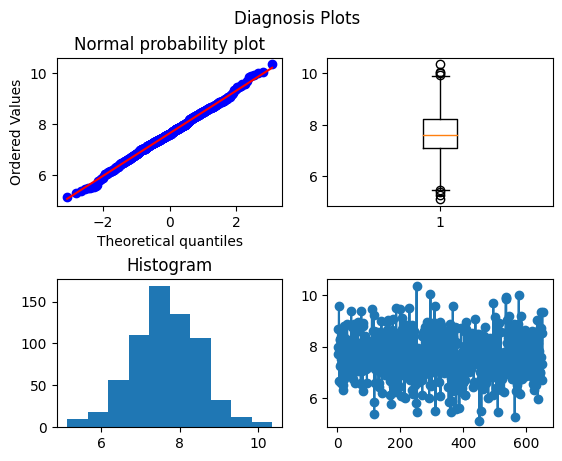

In [336]:
data_to_plot = p1_data_BC_2
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\qdatoolkit\models.py:723: UserWarning: A numpy array was passed to the Assumptions class and converted to Pandas Series.
Note that all other methods in qda-toolkit only accept Pandas Series or Pandas Dataframe.
  warnings.warn(


Runs test statistic = -0.640
Runs test p-value = 0.522



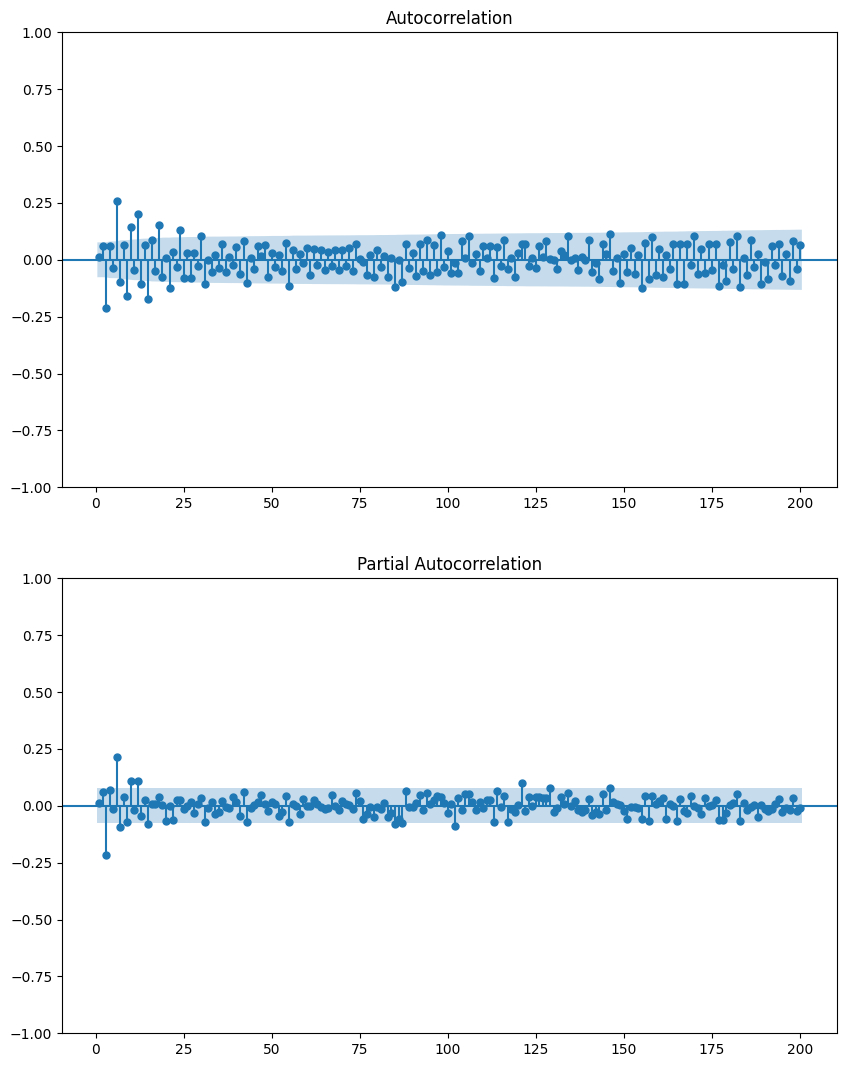

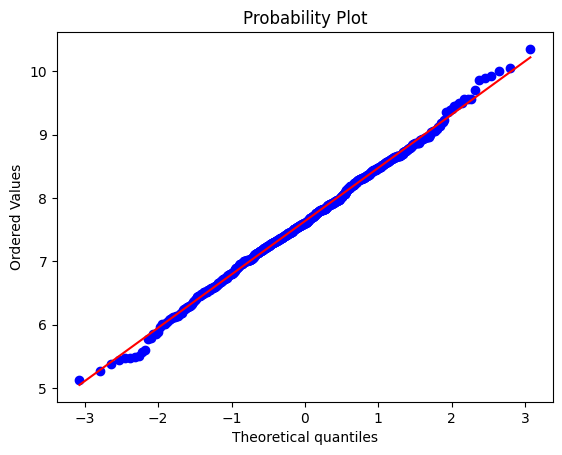

Shapiro-wilk test statistic = 0.998
Shapiro-wilk test p-value = 0.550


In [337]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

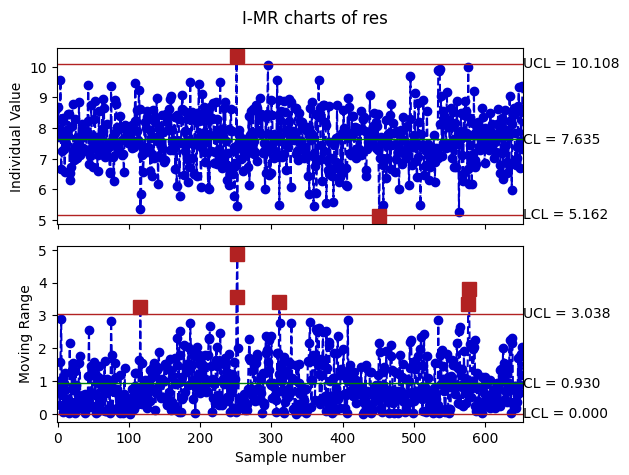

In [338]:
df_res = pd.DataFrame({'res': p1_data_BC_2})
df_res= qda.ControlCharts.IMR(df_res, 'res',K=3)

This is new phase 1 charts using a box cox transformation with a shift of +40 and a lambda of 0.36. 
Now, let us get the phase 2 residuals acquired by fitting the model of phase 1 directly on phase 2 data, and apply the same transformations

In [339]:
p2_data_BC_2 = stats.boxcox(p2_residuals_2+40,lmbda = 0.36)

In [340]:
data_to_plot = p2_data_BC_2

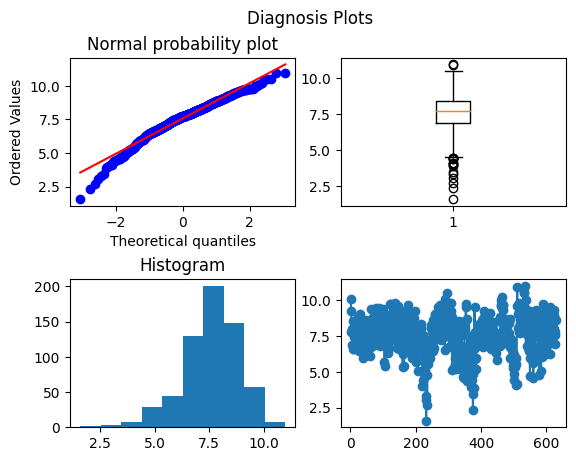

In [341]:
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

c:\Users\atari\anaconda3\envs\QDA_environment_WIN\lib\site-packages\qdatoolkit\models.py:723: UserWarning: A numpy array was passed to the Assumptions class and converted to Pandas Series.
Note that all other methods in qda-toolkit only accept Pandas Series or Pandas Dataframe.
  warnings.warn(


Runs test statistic = -7.687
Runs test p-value = 0.000



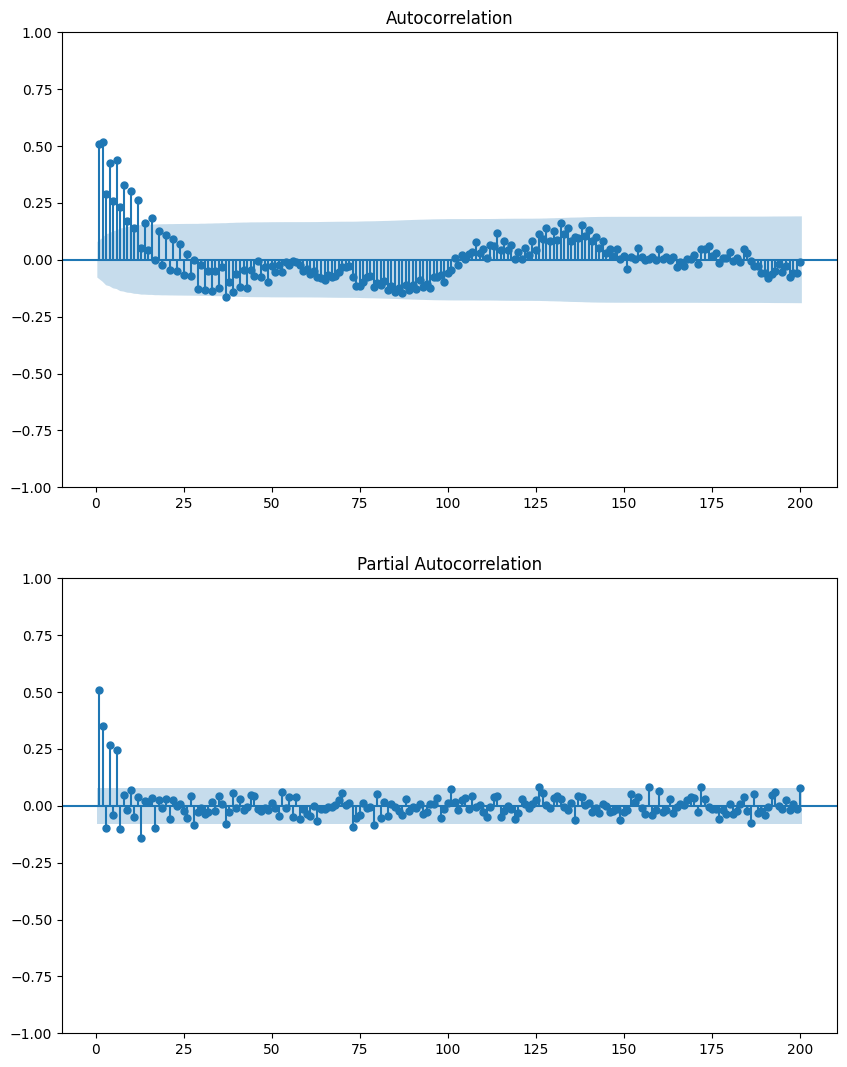

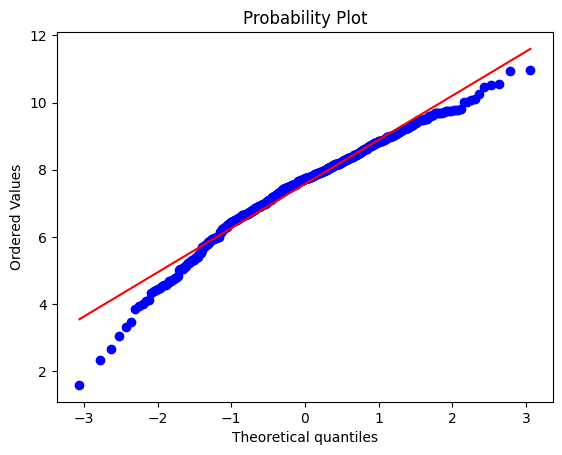

Shapiro-wilk test statistic = 0.971
Shapiro-wilk test p-value = 0.000


In [342]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

No need to try further, residuals acquired by fitting the exact model in phase 1 in phase 2 data does not produce residuals that are IID.

- **Results**

The ARIMA(1,0,2) model from Phase 1 performed well on the new dataset. Residuals, once Box-Cox transformed, retained independence and normality, validating the robustness of this approach across different print sections. The resulting I-MR control chart was clean, interpretable, and consistent with expectations. No large clusters of out-of-control points were observed, suggesting continued process stability, though some scattered points might reflect normal variation or potential localized spikes.

Importantly, if the same ARIMA parameters used in Phase 1 are applied to Phase 2 data to fit a new model with new coefficients, a satisfactory model is achieved. In this case, new control charts can be created with great success, producing well-behaved residuals that satisfy the necessary Shewhart assumptions.

Moreover, when the Box-Cox transformation from Phase 1 is adjusted for the new shift required in Phase 2, and the same transformation logic is applied, it becomes possible to plot Phase 2 residuals directly on the Phase 1 control charts, reusing the original control limits. This approach yields relatively strong results, with control limits maintaining their discriminative power on the new data.

However, if the exact same model from Phase 1 is applied to Phase 2 data without updating coefficients, the resulting residuals are not IID, and the control chart becomes invalid. Thus, the attempt to reuse the full model structure and coefficients from Phase 1 fails, but the strategy of retaining ARIMA parameters while refitting coefficients and reapplying the transformation yields success.

This highlights a critical nuance: structural generalizability is retained, but direct transfer of coefficients is not, due to temporal and process drift across builds.

# Approach 3 - Minimum Value for Each Track Across Adjacent Layers

- **Assumptions and Preliminary Data Analysis**

This approach tests the third and final model selected in Phase 1: monitoring minimum melt pool temperature values across tracks and layers to detect low-temperature anomalies such as porosity-inducing cold spots. The assumption is that these minima behave consistently across layers and thus can be modeled for control charting.

Data preprocessing followed a similar approach to that used in the Phase 1 model. Tracks with fewer than 20% of the average size were removed, followed by IQR-based filtering to eliminate extreme low outliers. Diagnostic plots (boxplot, histogram, Q-Q plot) showed a skewed but manageable distribution, with independence and normality verified post-cleaning.

The cleaned minimum values sequence was found to be suitable for ARIMA modeling, mirroring the Phase 1 conditions with minimal adjustments.

- **Proposed Methodology**

As in Phase 1, an ARIMA(0,2,1) model with a constant was used on the cleaned series of minimum values. After residual extraction, assumption checks were carried out. In this case, no Box-Cox transformation was required, and the residuals were sufficiently normal and independent following basic IQR-based outlier removal.

An I-MR control chart was constructed on the residuals using ±3σ limits derived from the Phase 2 model. To further evaluate model portability, an additional test was conducted: the Phase 1 ARIMA model was directly fitted to Phase 2 data, and predictions were compared against actuals to assess residual behavior.

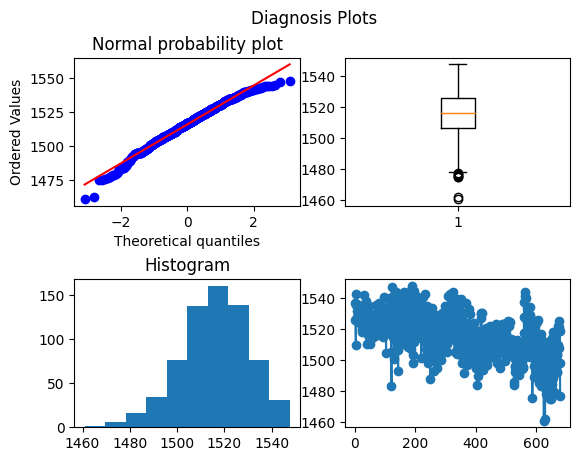

In [343]:
data_to_plot = track_agg_ml_clean["min"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

In [344]:
Q1 = track_agg_ml_clean['min'].quantile(0.25)
Q3 = track_agg_ml_clean['min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

track_agg_ml_cleaner2 = track_agg_ml_clean[(track_agg_ml_clean['min'] > lower_bound) & 
                     (track_agg_ml_clean['min'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", track_agg_ml_clean["mean"].count()-track_agg_ml_cleaner2["mean"].count() )

The # of rows dropped = 8


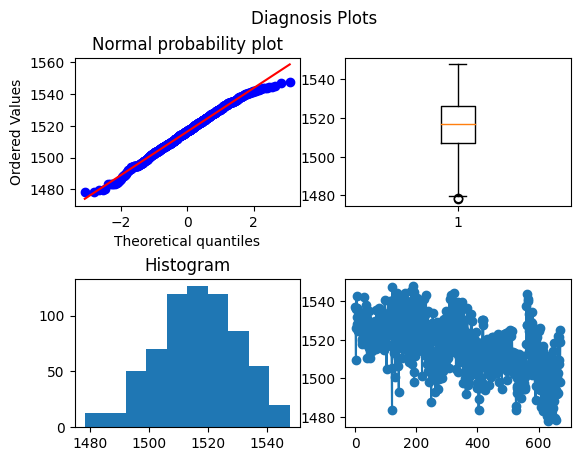

In [345]:
data_to_plot = track_agg_ml_cleaner2["min"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = -4.274
Runs test p-value = 0.000



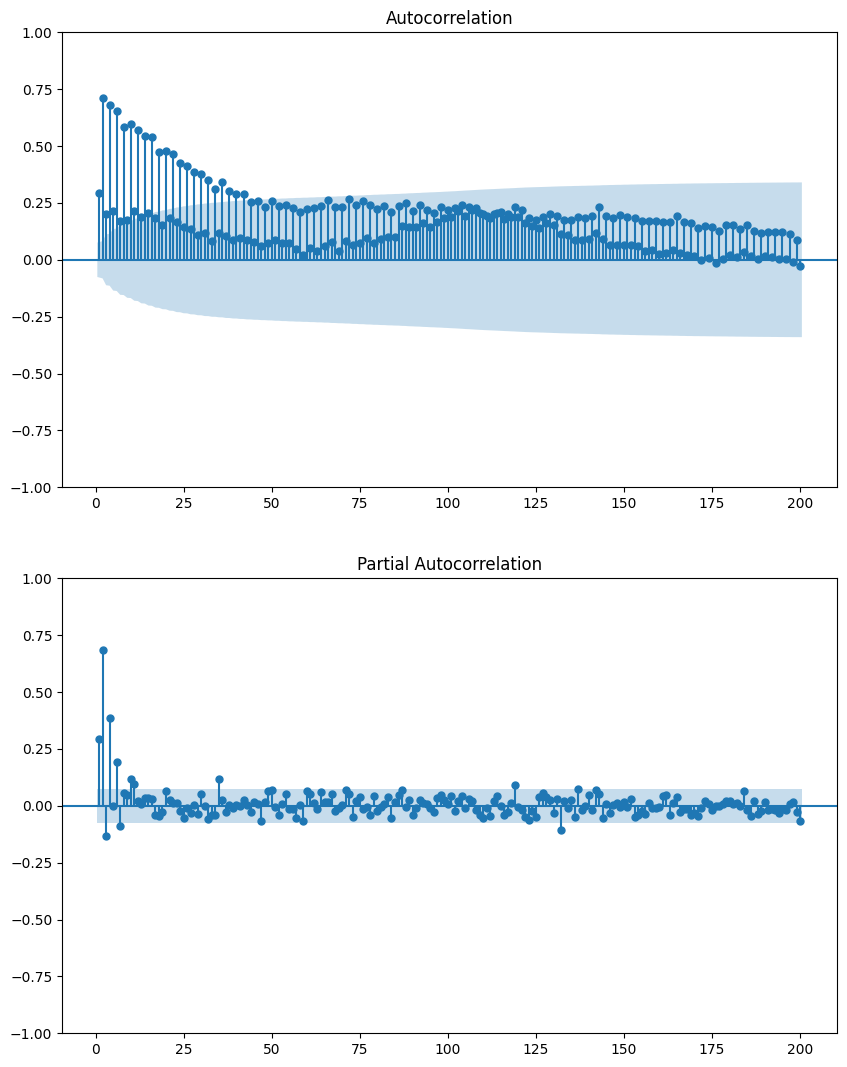

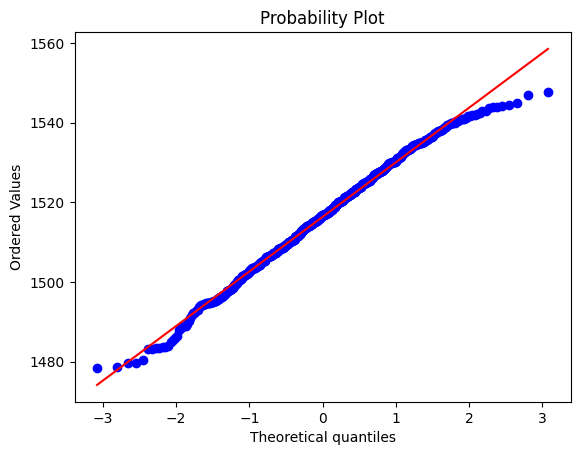

Shapiro-wilk test statistic = 0.993
Shapiro-wilk test p-value = 0.003


In [346]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=0, d=2, q=1

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value     P-Value
const -0.0857   0.6045  -0.1417  8.8731e-01
ma.L1  0.6126   0.0261  23.4520 1.2605e-121

RESIDUAL SUM OF SQUARES
-------------------------
   DF         SS      MS
667.0 62255.7086 93.3369

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12     98.3109 1.1920e-15
  24    117.9302 2.2640e-14
  36    145.8338 3.6529e-15
  48    156.4300 2.0557e-13
Runs test statistic = 2.979
Runs test p-value = 0.003



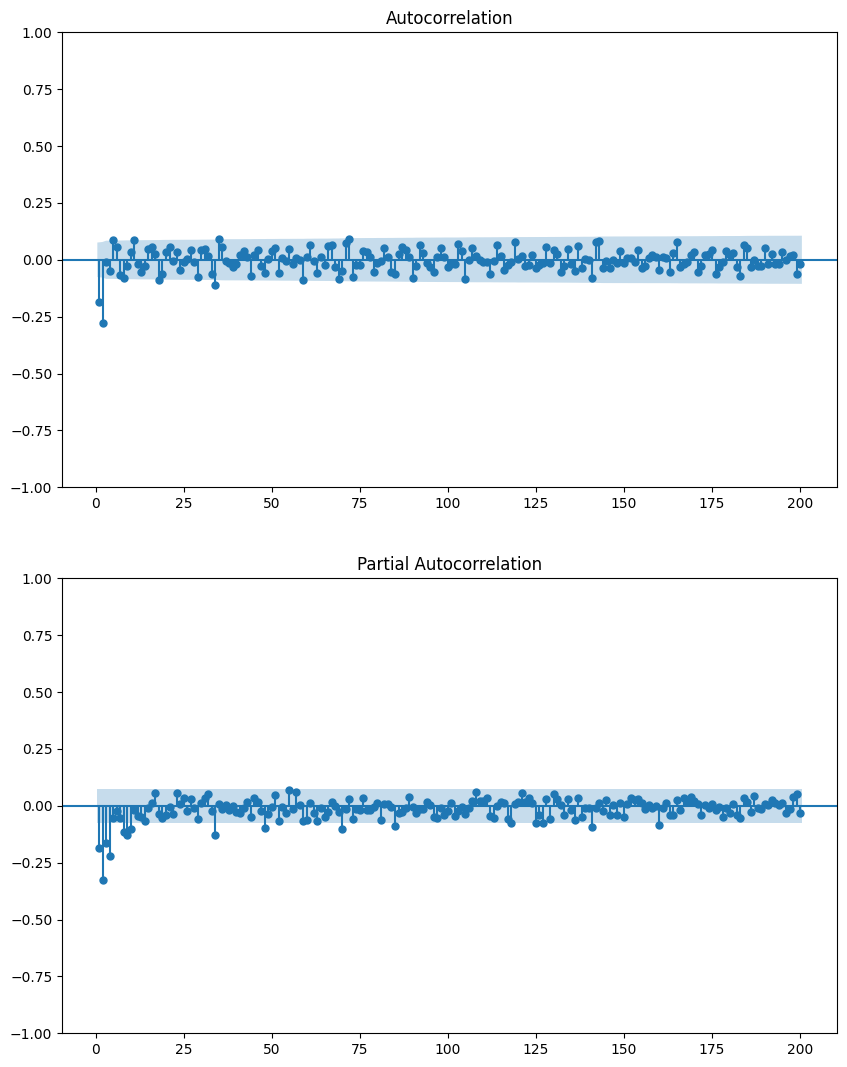

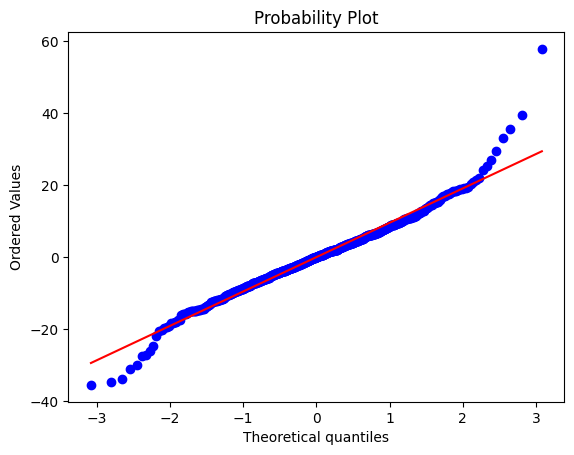

Shapiro-wilk test statistic = 0.972
Shapiro-wilk test p-value = 0.000


In [347]:
d = 2
model = qda.ARIMA(track_agg_ml_cleaner2["min"], order=(0,d,1), add_constant=True)
qda.ARIMAsummary(model)

residuals = model.resid[d:].dropna()
_ = qda.Assumptions(residuals).independence()
_ = qda.Assumptions(residuals).normality()

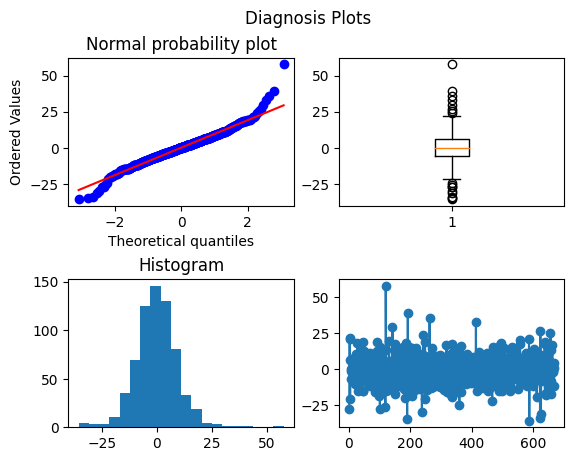

In [348]:
data_to_plot = residuals
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot,bins = 20)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

In [349]:
track_agg_ml_cleaner2["residuals"] = model.resid
track_agg_ml_cleaner2 = track_agg_ml_cleaner2.dropna()
track_agg_ml_cleaner2["residuals"]

2     -27.2147
3      21.9444
4      20.9736
5     -20.1693
6       6.2180
        ...   
666    -0.9924
667    -1.4877
668     4.4404
669   -11.8049
670     1.1025
Name: residuals, Length: 669, dtype: float64

In [350]:
Q1 = track_agg_ml_cleaner2['residuals'].quantile(0.25)
Q3 = track_agg_ml_cleaner2['residuals'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

track_agg_ml_cleaner_res = track_agg_ml_cleaner2[(track_agg_ml_cleaner2['residuals'] > lower_bound) & 
                     (track_agg_ml_cleaner2['residuals'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", track_agg_ml_cleaner2["mean"].count()-track_agg_ml_cleaner_res["mean"].count() )

The # of rows dropped = 17


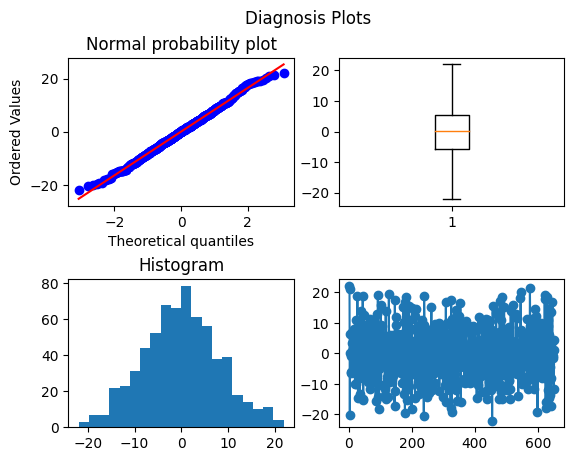

In [351]:
data_to_plot = track_agg_ml_cleaner_res["residuals"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot,bins = 20)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = 2.352
Runs test p-value = 0.019



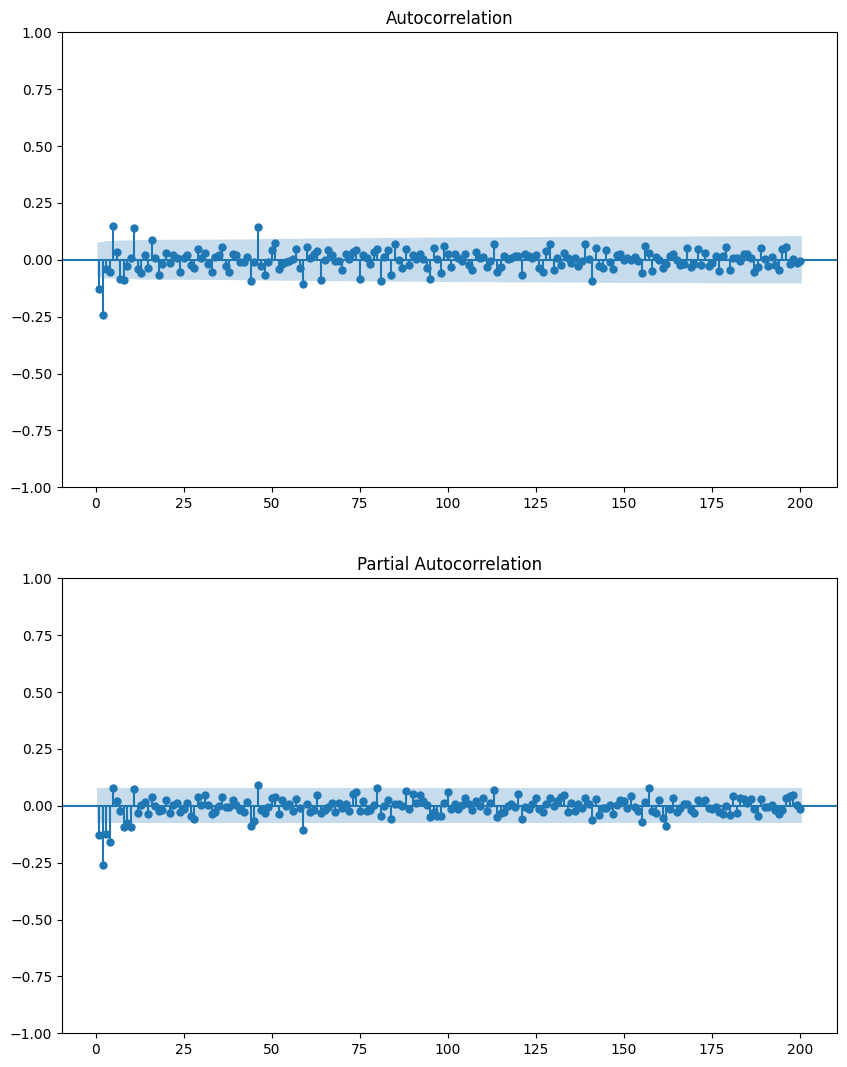

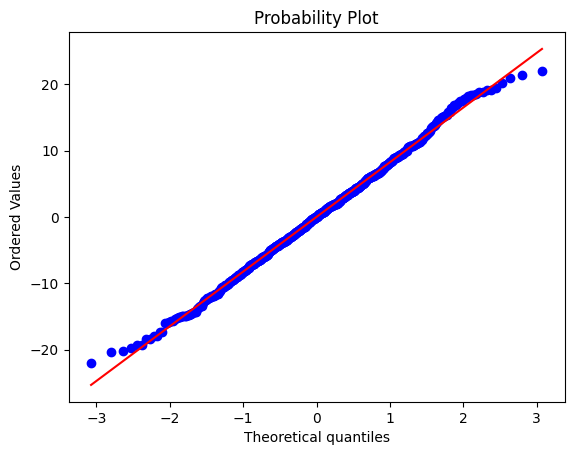

Shapiro-wilk test statistic = 0.997
Shapiro-wilk test p-value = 0.313


In [352]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

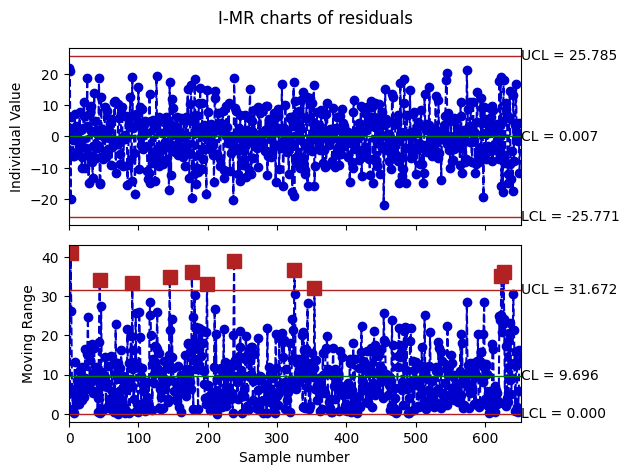

In [353]:
df_res= qda.ControlCharts.IMR(track_agg_ml_cleaner_res, "residuals",K=3)

Lets see how the charts will look with the same limits as the previous ones

In [354]:
df_res2 = df_res[["residuals","I_UCL","I_CL","I_LCL","MR","MR_UCL","MR_CL","MR_LCL"]]

In [355]:
df_res2["I_CL"] = 0.059
df_res2["I_UCL"] = 23.982
df_res2["I_LCL"] = -23.865
df_res2["MR_CL"] = 8.998
df_res2["MR_UCL"] = 29.393
df_res2["MR_LCL"] = 0
df_res2['I_TEST1'] = np.where((df_res2["residuals"] > df_res2['I_UCL']) | (df_res2["residuals"] < df_res2['I_LCL']), df_res2["residuals"], np.nan)
df_res2['MR_TEST1'] = np.where((df_res2['MR'] > df_res2['MR_UCL']) | (df_res2['MR'] < df_res2['MR_LCL']), df_res2['MR'], np.nan)

In [356]:
df_res2

,residuals,I_UCL,I_CL,I_LCL,MR,MR_UCL,MR_CL,MR_LCL,I_TEST1,MR_TEST1
0,21.9444,23.982,0.059,-23.865,NaN,29.393,8.998,0,NaN,NaN
1,20.9736,23.982,0.059,-23.865,0.9708,29.393,8.998,0,NaN,NaN
2,-20.1693,23.982,0.059,-23.865,41.1429,29.393,8.998,0,NaN,41.1429
3,6.2180,23.982,0.059,-23.865,26.3873,29.393,8.998,0,NaN,NaN
4,0.0454,23.982,0.059,-23.865,6.1726,29.393,8.998,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
647,-0.9924,23.982,0.059,-23.865,1.7806,29.393,8.998,0,NaN,NaN
648,-1.4877,23.982,0.059,-23.865,0.4953,29.393,8.998,0,NaN,NaN
649,4.4404,23.982,0.059,-23.865,5.9281,29.393,8.998,0,NaN,NaN
650,-11.8049,23.982,0.059,-23.865,16.2453,29.393,8.998,0,NaN,NaN


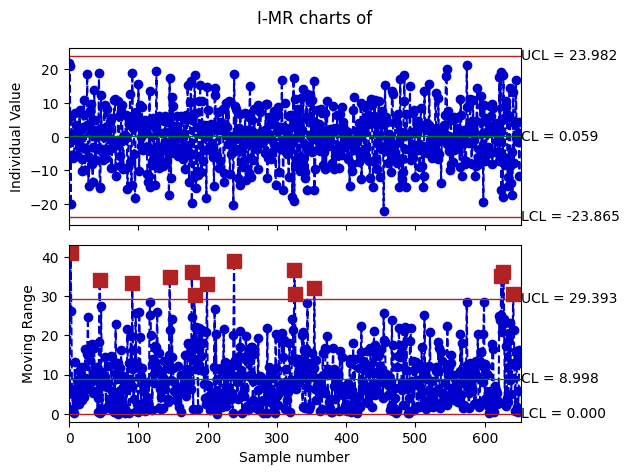

In [357]:
            # Plot the I and MR charts
            fig, ax = plt.subplots(2, 1, sharex=True)
            fig.suptitle(('I-MR charts of'))
            ax[0].plot(df_res2['residuals'], color='mediumblue', linestyle='--', marker='o')
            ax[0].plot(df_res2['I_UCL'], color='firebrick', linewidth=1)
            ax[0].plot(df_res2['I_CL'], color='g', linewidth=1)
            ax[0].plot(df_res2['I_LCL'], color='firebrick', linewidth=1)
            ax[0].set_ylabel('Individual Value')
            ax[1].set_xlabel('Sample number')
            # add the values of the control limits on the right side of the plot
            ax[0].text(len(df_res2)+.5, df_res2['I_UCL'].iloc[0], 'UCL = {:.3f}'.format(df_res2['I_UCL'].iloc[0]), verticalalignment='center')
            ax[0].text(len(df_res2)+.5, df_res2['I_CL'].iloc[0], 'CL = {:.3f}'.format(df_res2['I_CL'].iloc[0]), verticalalignment='center')
            ax[0].text(len(df_res2)+.5, df_res2['I_LCL'].iloc[0], 'LCL = {:.3f}'.format(df_res2['I_LCL'].iloc[0]), verticalalignment='center')
            # highlight the points that violate the alarm rules
            ax[0].plot(df_res2['I_TEST1'], linestyle='none', marker='s', color='firebrick', markersize=10)
            ax[0].set_xlim(-1, len(df_res2))

            ax[1].plot(df_res2['MR'], color='mediumblue', linestyle='--', marker='o')
            ax[1].plot(df_res2['MR_UCL'], color='firebrick', linewidth=1)
            ax[1].plot(df_res2['MR_CL'], color='g', linewidth=1)
            ax[1].plot(df_res2['MR_LCL'], color='firebrick', linewidth=1)
            ax[1].set_ylabel('Moving Range')
            ax[1].set_xlabel('Sample number')
            # add the values of the control limits on the right side of the plot
            ax[1].text(len(df_res2)+.5, df_res2['MR_UCL'].iloc[0], 'UCL = {:.3f}'.format(df_res2['MR_UCL'].iloc[0]), verticalalignment='center')
            ax[1].text(len(df_res2)+.5, df_res2['MR_CL'].iloc[0], 'CL = {:.3f}'.format(df_res2['MR_CL'].iloc[0]), verticalalignment='center')
            ax[1].text(len(df_res2)+.5, df_res2['MR_LCL'].iloc[0], 'LCL = {:.3f}'.format(df_res2['MR_LCL'].iloc[0]), verticalalignment='center')
            # highlight the points that violate the alarm rules
            ax[1].plot(df_res2['MR_TEST1'], linestyle='none', marker='s', color='firebrick', markersize=10)
            ax[1].set_xlim(-1, len(df_res2))
            # set the x-axis limits
            ax[1].set_xlim(-1, len(df_res2))
            plt.tight_layout()
            plt.show()

There is no transformation required for residuals of this approach, so no trial for that is required. However, we can try fitting the model of Phase 1 directly on phase 2 data as we tried in approach 2:

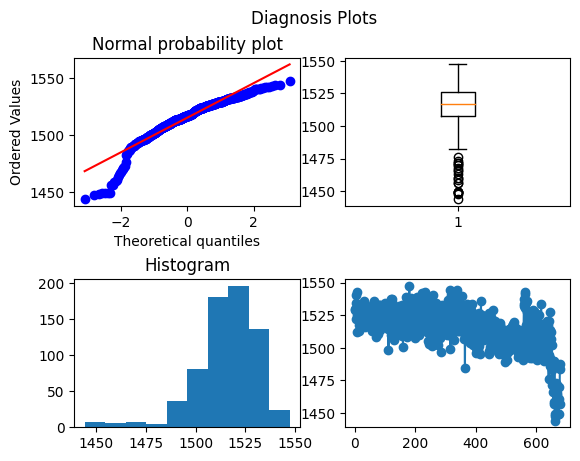

In [358]:
data_to_plot = p1_track_agg_ml_clean["min"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

In [362]:
Q1 = p1_track_agg_ml_clean['min'].quantile(0.25)
Q3 = p1_track_agg_ml_clean['min'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

p1_track_agg_ml_cleaner2 = p1_track_agg_ml_clean[(p1_track_agg_ml_clean['min'] > lower_bound) & 
                     (p1_track_agg_ml_clean['min'] < upper_bound)].reset_index(drop=True)

print("The # of rows dropped =", p1_track_agg_ml_clean["mean"].count()-p1_track_agg_ml_cleaner["mean"].count() )


The # of rows dropped = 22


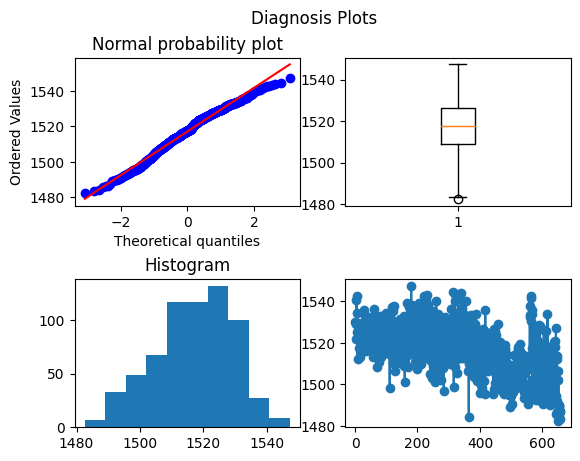

In [363]:
data_to_plot = p1_track_agg_ml_cleaner2["min"]
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = -2.288
Runs test p-value = 0.022



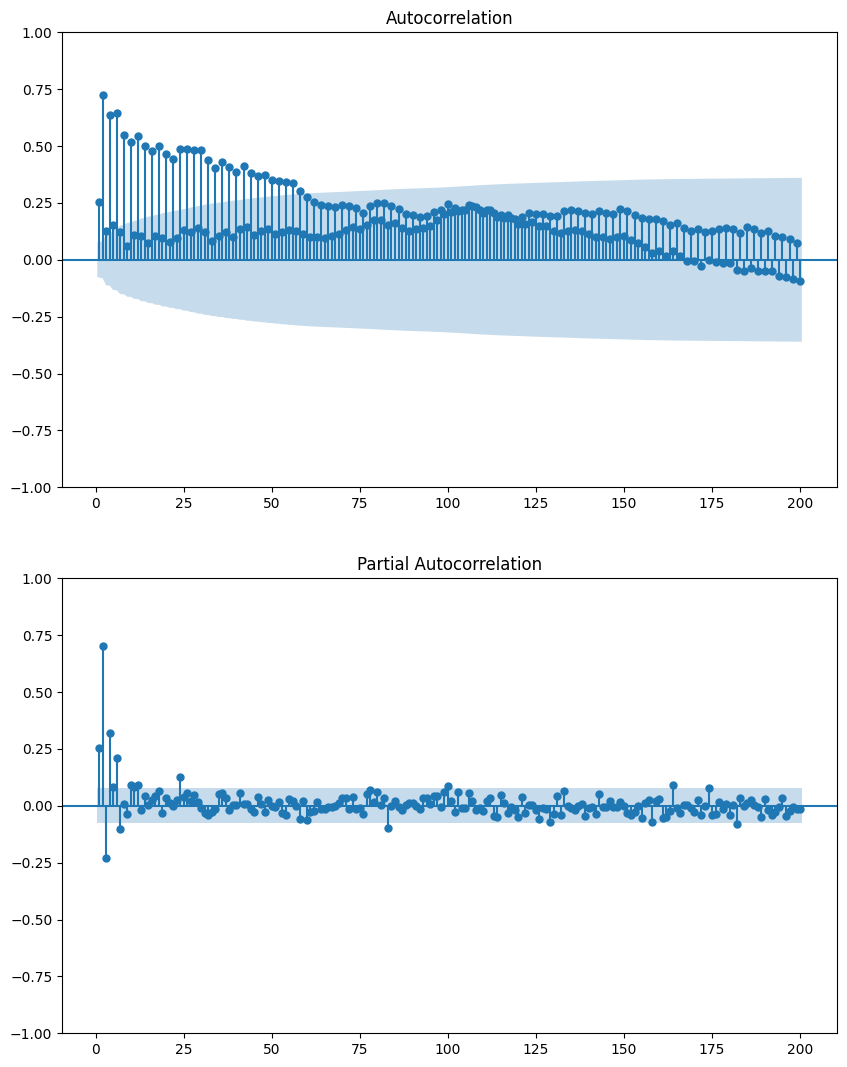

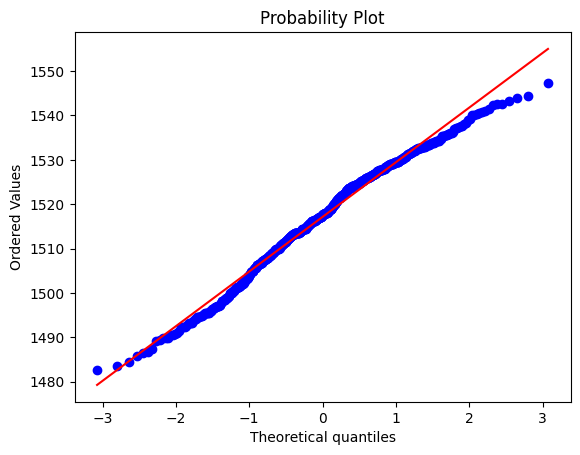

Shapiro-wilk test statistic = 0.987
Shapiro-wilk test p-value = 0.000


In [364]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

In [374]:
d = 2
model = qda.ARIMA(p1_track_agg_ml_cleaner2["min"], order=(0,d,1), add_constant=True)
qda.ARIMAsummary(model)

---------------------
ARIMA MODEL RESULTS
---------------------
ARIMA model order: p=0, d=2, q=1

FINAL ESTIMATES OF PARAMETERS
-------------------------------
 Term    Coef  SE Coef  T-Value     P-Value
const -0.1465   0.5105  -0.2871  7.7407e-01
ma.L1  0.5567   0.0233  23.8765 5.3751e-126

RESIDUAL SUM OF SQUARES
-------------------------
   DF         SS      MS
653.0 45747.0814 70.0568

Ljung-Box Chi-Square Statistics
----------------------------------
 Lag  Chi-Square    P-Value
  12    119.0142 9.7157e-20
  24    140.0640 2.2672e-18
  36    154.4660 1.2757e-16
  48    173.9489 3.5649e-16


Let's make predictions with this model on phase 2 data and calulate the residuals from that:

In [375]:
track_agg_ml_cleaner_res["residuals"]

0      21.9444
1      20.9736
2     -20.1693
3       6.2180
4       0.0454
        ...   
647    -0.9924
648    -1.4877
649     4.4404
650   -11.8049
651     1.1025
Name: residuals, Length: 652, dtype: float64

In [376]:
predictions = model.predict(end = 651)
p2_residuals_3 = track_agg_ml_cleaner_res["min"] - predictions
p2_residuals_3 = p2_residuals_2.dropna()

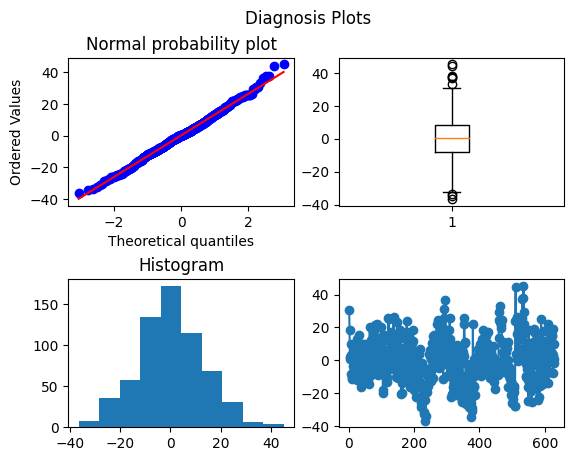

In [378]:
data_to_plot = p2_residuals_3
fig, axs = plt.subplots(2, 2)
fig.suptitle('Diagnosis Plots')
stats.probplot(data_to_plot, dist="norm", plot=axs[0,0])
axs[0,0].set_title('Normal probability plot')
axs[0,1].boxplot(data_to_plot)
fig.subplots_adjust(hspace=0.5)
axs[1,0].hist(data_to_plot)
axs[1,0].set_title('Histogram')
axs[1,1].plot(np.arange(1, len(data_to_plot)+1), data_to_plot, 'o-')
plt.show()

Runs test statistic = -6.903
Runs test p-value = 0.000



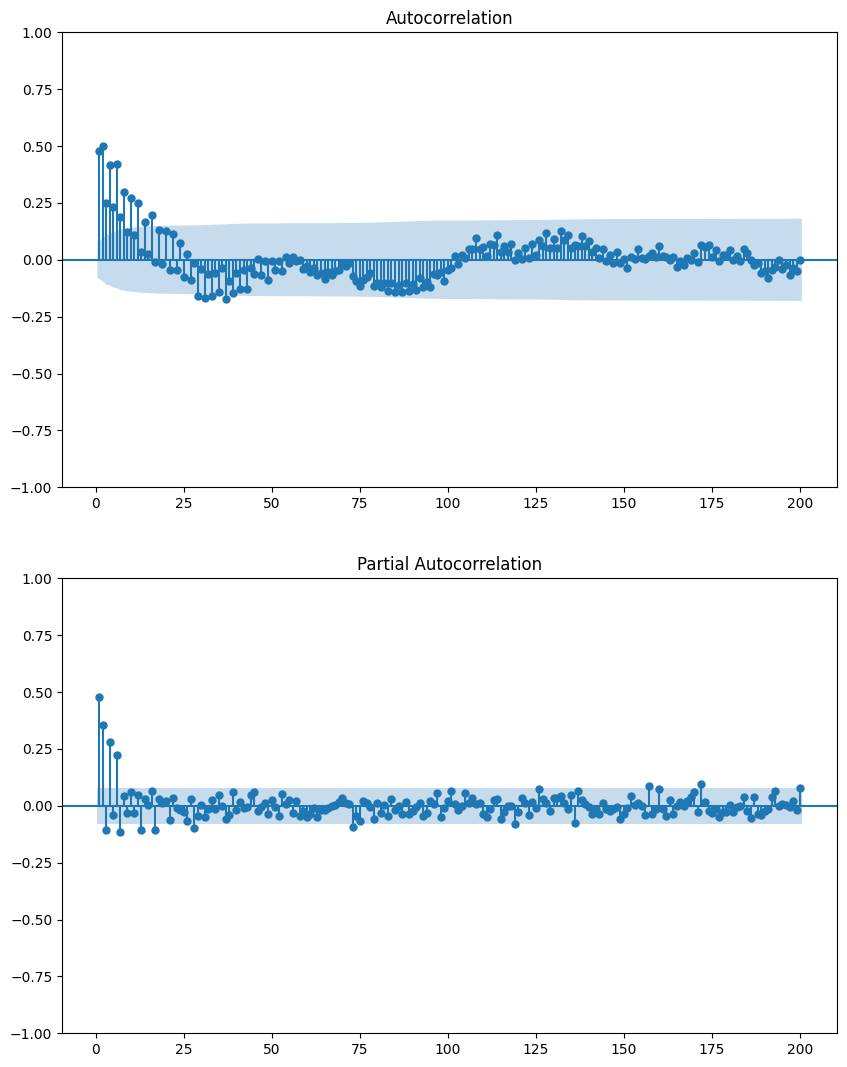

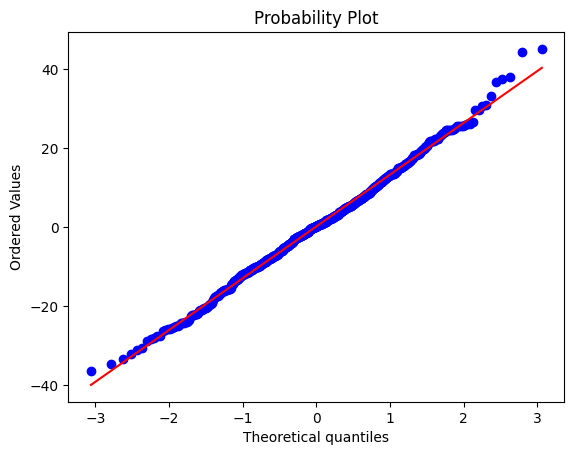

Shapiro-wilk test statistic = 0.997
Shapiro-wilk test p-value = 0.252


In [379]:
_ = qda.Assumptions(data_to_plot).independence()
_ = qda.Assumptions(data_to_plot).normality()

Independence is not satisfied

- **Results**

The ARIMA(0,2,1) model applied to Phase 2 data performed successfully when the model was refit using the same ARIMA parameters but new coefficients. The residuals were stable and independent, allowing for the construction of valid I-MR control charts. The charts were interpretable and consistent with expectations, capturing both process stability and mild anomalies.

Notably, no Box-Cox transformation was necessary, simplifying the residual conditioning. This further strengthens the model’s usability across datasets.

When residuals from the Phase 2 fit were plotted on the Phase 1 control chart limits, the approach still worked with good accuracy. This confirms that not only are the ARIMA parameters generalizable, but the residual distribution remains sufficiently aligned to reuse control limits—improving practicality and deployment speed.

Just like in Attempt 2 (model for max values), if the same ARIMA parameters used in Phase 1 are applied to Phase 2 data to fit a new model with new coefficients, a satisfactory model is achieved and new control charts can be created with great success.

However, if the exact model from Phase 1 is directly applied to Phase 2 data without refitting coefficients, the resulting residuals are not IID. Therefore, the attempt to reuse the Phase 1 model fully fails, but using the same ARIMA parameters to refit a model for Phase 2 and then plotting the residuals on Phase 1 control limits is successful.

In summary, this model remains robust and transferable across builds as long as the ARIMA model is refit on new data using the same parameter structure, reaffirming its value for monitoring low-temperature anomalies in LPBF processes.

## Conclusion 

Phase 2 of this project set out to evaluate the robustness and generalizability of the statistical process monitoring models developed during Phase 1. Specifically, it tested whether the selected control chart methodologies—focused on monitoring track-wise mean, maximum, and minimum melt pool temperatures—could effectively detect anomalies when applied to new, previously unseen data from the second half of the LPBF print job.

The results showed a clear contrast in generalization performance across the three models. The model relying on track-wise mean temperatures within a single layer, which had shown promise during Phase 1, did not perform well when applied to new data. Using the same ARIMA parameters and coefficients from Phase 1 failed to produce IID residuals in Phase 2, and the model required substantial reconfiguration to regain usability. As a result, this approach was found to be ineffective in terms of direct generalization and unsuitable for real-time deployment without retraining.

On the other hand, the models built on maximum and minimum temperature values across tracks and layers proved to be significantly more robust. When the same ARIMA order parameters from Phase 1 were used to fit new models (with updated coefficients) on the Phase 2 dataset, both models achieved excellent fits. The residuals were statistically well-behaved—independent, stable, and in many cases, normally distributed—enabling the construction of valid I-MR control charts. Moreover, the residuals derived from these Phase 2 models could be plotted directly onto the control charts created during Phase 1, using the original control limits. This ability to reuse control limits without recalibrating the entire model adds considerable value in terms of operational efficiency and interpretability.

However, it is important to emphasize that the full reuse of Phase 1 models—including coefficients—did not succeed. When directly applied to the new data, these models yielded residuals that were not IID, breaking one of the fundamental assumptions required for control charting. This outcome underscores the presence of natural process drift or subtle shifts in operating conditions between the two halves of the print job, which make coefficient-level generalization unrealistic.

Despite this limitation, the findings from Phase 2 confirm that structural generalizability—preserving the ARIMA order while refitting the model—can be achieved successfully. In particular, the models monitoring maximum and minimum values across layers offer a strong balance of sensitivity, scalability, and interpretability. These models can be readily adapted to new builds with minimal rework and are well-suited for detecting both localized and systemic thermal anomalies in LPBF processes.

In conclusion, Phase 2 validates the practical relevance of the models based on extreme temperature values. While the model focused on track means within a single layer lacked the robustness required for broader application, the other two approaches demonstrated clear potential for implementation in real-world monitoring systems. This outcome marks an important step forward in designing data-driven quality control tools for additive manufacturing.
